# Zero-Shot HAR on PAMAP2 — Consolidated Pipeline

A single, self-contained pipeline for zero-shot human activity recognition from IMU
data. It trains a TCN sensor encoder via contrastive alignment to **discriminative**
Sentence-BERT prototypes, and evaluates three inference methods on top of it.

**Pipeline overview**

- Only the contrastive-discriminative encoder is trained. Label-name prototype
  similarity values are retained *as a reference baseline* in comparison plots
  (no second encoder is trained for this).
- The seen/unseen split is **fully parameterised** (`UNSEEN_IDS`), and the
  unseen test set is **automatically balanced by augmentation** when — and only
  when — it is severely imbalanced.
- **Hubness diagnostics have been removed.** No configuration ever showed
  significant hubness, so the skewness/hub-class machinery is gone. Inverted
  Softmax (ISF) is *kept* because it improves macro F1, reframed as a
  score-redistribution correction rather than a hubness fix.
- A clearly-marked slot is **reserved** for the LLM-generated +
  separability-filtered prototype construction (Section 9).

**Primary metric: macro F1** (equal weight per unseen class). Overall accuracy
and balanced accuracy are reported alongside.


## 1. Setup

Imports, fixed random seed, and device selection. The seed makes the split, augmentation, and training reproducible.

In [129]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, balanced_accuracy_score)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from collections import Counter

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
CMAP = "Blues"

# UNSEEN_IDS      = [5, 13, 16, 18] 
# # UNSEEN_IDS      = [1, 2, 3, 4]
VAL_UNSEEN_IDS  = [7, 12, 24]      # proxy-unseen classes: excluded from training,
                                   # used ONLY to select beta / hyperparameters

# UNSEEN_IDS      = [1, 10, 12, 19]
UNSEEN_IDS      = [1, 10, 12, 16]
# UNSEEN_IDS      = [5, 13, 16, 18]

dir_string = "_".join(map(str, UNSEEN_IDS))

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = torch.device("mps")
NUM_WORKERS = 0
os.environ["TOKENIZERS_PARALLELISM"] = "false"

VIS_DIR = f"visualisations_modified_{dir_string}"
os.makedirs(VIS_DIR, exist_ok=True)
print(f"Visualisations: {os.path.abspath(VIS_DIR)}")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Visualisations: /Users/anikghosh/Desktop/test/Zero Shot Learning/visualisations_modified_1_10_12_16
Device  : mps
PyTorch : 2.11.0


## 2. Activity Labels & Semantic Descriptions

`ACTIVITY_MAP` holds the PAMAP2 activity IDs. `DISCRIMINATIVE_DESC` holds one biomechanical sentence per class — these descriptions serve **two roles**: they are the contrastive *training targets* for the encoder and the *matching targets* at inference. Section 9 will replace this hand-written dictionary with an automatically-constructed, separability-optimised set.

In [130]:
ACTIVITY_MAP = {
    1:  "lying",            2:  "sitting",          3:  "standing",
    4:  "walking",          5:  "running",           6:  "cycling",
    7:  "Nordic walking",   9:  "watching TV",       10: "computer work",
    11: "car driving",      12: "ascending stairs",  13: "descending stairs",
    16: "vacuum cleaning",  17: "ironing",           18: "folding laundry",
    19: "house cleaning",   20: "playing soccer",    24: "rope jumping",
}

# UNSEEN_IDS      = [2, 12, 17, 20]

# Vocabulary chosen to maximise inter-class SBERT distance.
# Similar pairs use mutually exclusive kinematic terms.
DISCRIMINATIVE_DESC = {
    1:  ("motionless horizontal body position, gravitational vector constant, "
         "zero voluntary limb movement, near-zero energy across all sensors"),
    2:  ("static seated trunk posture, spine vertical, pelvis fixed, "
         "negligible foot and leg movement, low wrist activity"),
    3:  ("upright bipedal stance with micro-balance corrections, "
         "no stepping or translational displacement, slow postural sway below 0.3 Hz"),
    4:  ("rhythmic heel-toe stepping at 1.8 Hz, coordinated arm pendulum swing, "
         "moderate vertical oscillation, periodic ground contact every 0.55 seconds"),
    5:  ("explosive aerial locomotion with full flight phase between footstrikes, "
         "impulsive vertical spike at ankle touchdown, 3 Hz stride cadence, "
         "peak acceleration exceeding 4g, high cardiovascular demand"),
    6:  ("circular pedalling with legs driving alternating downward thrust, "
         "seated upper body stationary, rhythmic knee extension at 80 rpm, "
         "no foot impact transients"),
    7:  ("walking cadence with simultaneous bilateral pole-plant impulses, "
         "elevated shoulder and elbow motion, upper limb load-bearing contact"),
    9:  ("prolonged resting with eyes forward, minimal voluntary motion, "
         "slow infrequent postural repositioning, very low metabolic rate"),
    10: ("seated fine motor hand and finger movements from keyboard and mouse, "
         "wrist flexion-extension below 1 Hz, torso stationary, no lower limb signal"),
    11: ("passive seated vibration from road surface transmitted through spine, "
         "steering micro-corrections at wrist, low voluntary whole-body movement"),
    12: ("staircase ascent with concentric quadriceps effort, upward body displacement "
         "per step, toe-push-off propulsion, increasing altitude, forward trunk lean"),
    13: ("staircase descent with eccentric braking at knee, heel-first step landing, "
         "controlled downward displacement, deceleration force at each footfall, "
         "backward trunk lean for balance"),
    16: ("slow forward-backward walking combined with bilateral appliance pushing "
         "and pulling, dominant wrist push-pull signal, floor-level trunk bending"),
    17: ("stationary standing with single-arm repetitive gliding strokes, "
         "smooth low-frequency wrist motion below 0.8 Hz, weight shift between feet"),
    18: ("bilateral symmetrical arm folding and garment manipulation while standing still, "
         "frequent wrist direction reversal, no lower body locomotion"),
    19: ("ambulation combined with wiping, reaching, and bending, "
         "mixed frequency trunk rotation, irregular step pattern during cleaning tasks"),
    20: ("explosive sprint bursts and rapid lateral direction changes, "
         "kicking impulse at foot, unpredictable acceleration magnitude, "
         "maximal cardiovascular output"),
    24: ("high-cadence symmetric two-foot jumping at 2.5 Hz with rope rotation "
         "at wrist, full vertical body displacement each cycle, near-maximal effort"),
}

assert set(DISCRIMINATIVE_DESC.keys()) == set(ACTIVITY_MAP.keys())
print("Discriminative descriptions defined for all 18 classes.")


Discriminative descriptions defined for all 18 classes.


## 3. Loading PAMAP2

Reads the raw `.dat` files into a single dataframe, attaching subject/session metadata. Set `DATA_ROOT` to your local PAMAP2 path.

In [3]:
DATA_ROOT = "PAMAP2_Dataset"   # <- set to your local path

def make_colnames():
    cols = ["timestamp", "label", "hr"]
    imu_parts = [
        "temp",
        "acc16_x","acc16_y","acc16_z",
        "acc6_x", "acc6_y", "acc6_z",
        "gyro_x", "gyro_y", "gyro_z",
        "mag_x",  "mag_y",  "mag_z",
        "ori_1",  "ori_2",  "ori_3",  "ori_4",
    ]
    for loc in ["hand","chest","ankle"]:
        cols += [f"{loc}_{p}" for p in imu_parts]
    return cols

COLS = make_colnames()

def load_all_sessions(data_root=DATA_ROOT):
    dfs = []
    for part in ["Protocol","Optional"]:
        folder = os.path.join(data_root, part)
        for f in sorted(glob.glob(os.path.join(folder,"subject*.dat"))):
            df = pd.read_csv(f, sep=r"\s+", header=None, names=COLS, engine="python")
            df["session"] = part.lower()
            df["subject"] = os.path.splitext(os.path.basename(f))[0]
            dfs.append(df)
    if not dfs:
        raise FileNotFoundError(f"No .dat files found under {data_root}")
    return pd.concat(dfs, ignore_index=True)

raw = load_all_sessions()
print(f"Raw data shape : {raw.shape}")
print(f"Subjects       : {sorted(raw['subject'].unique())}")
print(f"Activity IDs   : {sorted(raw['label'].dropna().astype(int).unique())}")


Raw data shape : (3850505, 56)
Subjects       : ['subject101', 'subject102', 'subject103', 'subject104', 'subject105', 'subject106', 'subject107', 'subject108', 'subject109']
Activity IDs   : [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 24]


## 4. Preprocessing

We keep 31 feature channels, dropping the high-range accelerometers (which saturate during intense activities) and orientation quaternions (unreliable across sessions). Heart rate is forward-filled.

In [8]:
ORI_COLS  = [c for c in COLS if "ori_"  in c]
ACC6_COLS = [c for c in COLS if "acc6_" in c]

def preprocess_pamap2(df, drop_orientation=True, drop_acc6=True,
                       keep_hr=True, max_nan_frac=0.30):
    df = df.copy()
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df = df[df["label"].notna()]
    df["label"] = df["label"].astype(int)
    df = df[df["label"] != 0].reset_index(drop=True)

    if drop_orientation: df = df.drop(columns=ORI_COLS,  errors="ignore")
    if drop_acc6:        df = df.drop(columns=ACC6_COLS, errors="ignore")
    if not keep_hr:      df = df.drop(columns=["hr"],    errors="ignore")

    for c in df.columns:
        if c not in ["subject","session"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    feat_cols = [c for c in df.columns
                 if c not in ["subject","session","label","timestamp"]]

    def impute_group(g):
        g = g.sort_values("timestamp")
        g[feat_cols] = g[feat_cols].interpolate(limit_direction="both")
        g[feat_cols] = g[feat_cols].ffill().bfill()
        return g

    df = df.groupby(["subject","session"], group_keys=False).apply(impute_group)
    nan_frac = df[feat_cols].isna().mean(axis=1)
    df = df[nan_frac <= max_nan_frac].reset_index(drop=True)
    return df.dropna().reset_index(drop=True)

df = preprocess_pamap2(raw)
print(f"Preprocessed shape : {df.shape}")
feat_cols_all = [c for c in df.columns if c not in ["subject","session","label","timestamp"]]
print(f"Feature columns    : {len(feat_cols_all)}")


Preprocessed shape : (2724953, 35)
Feature columns    : 31


## 5. Windowing

Training windows are 1000 frames (5 s) with 50% overlap; test windows are 1000 frames (10 s). A purity threshold keeps only windows that are ≥85% a single activity, so each window has a clean majority label.

In [70]:
FEATURE_COLS      = feat_cols_all
WINDOW_SIZE_TRAIN = 1000
WINDOW_SIZE_TEST  = 1000
STRIDE_TRAIN      = 250
STRIDE_TEST       = 500
PURITY_THRESH     = 0.85

def make_windows(df, feature_cols, window_size, stride, purity_thresh):
    X, y, pur, meta = [], [], [], []
    for (subject, session), g in df.groupby(["subject","session"]):
        g      = g.sort_values("timestamp")
        values = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g["label"].to_numpy(dtype=np.int64)
        n      = len(g)
        for start in range(0, n - window_size + 1, stride):
            end    = start + window_size
            wlab   = labels[start:end]
            binc   = np.bincount(wlab)
            maj    = int(binc.argmax())
            purity = float(binc.max()) / window_size
            if purity < purity_thresh:
                continue
            X.append(values[start:end]); y.append(maj)
            pur.append(purity); meta.append((subject, session))
    if X:
        X = np.stack(X)
    else:
        X = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
    y    = np.array(y,   dtype=np.int64)
    pur  = np.array(pur, dtype=np.float32)
    meta = pd.DataFrame(meta, columns=["subject","session"])
    return X, y, pur, meta

X_trw, y_trw, pur_tr, meta_tr = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TRAIN, STRIDE_TRAIN, PURITY_THRESH)
X_tew, y_tew, pur_te, meta_te = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TEST,  STRIDE_TEST,  PURITY_THRESH)

print(f"Train/Val windows ({WINDOW_SIZE_TRAIN} frames): {X_trw.shape}  avg purity: {pur_tr.mean():.3f}")
print(f"Test windows      ({WINDOW_SIZE_TEST} frames): {X_tew.shape}  avg purity: {pur_te.mean():.3f}")


Train/Val windows (1000 frames): (10539, 1000, 31)  avg purity: 0.999
Test windows      (1000 frames): (5265, 1000, 31)  avg purity: 0.999


## 6. Parameterised Seen/Unseen Split

The split is driven entirely by `UNSEEN_IDS` — change it and the whole pipeline (prototypes, training, evaluation) adapts. Test subjects are held out entirely. Macro F1 is the primary metric because the unseen test set is class-imbalanced and overall accuracy can be dominated by one large class.

In [131]:
# ─── Seen/Unseen split parameterisation ─────────────────────────────────────────
# UNSEEN_IDS      = [5, 13, 16, 18]
# UNSEEN_IDS      = [2, 12, 17, 20]
N_UNSEEN        = len(UNSEEN_IDS)
N_TEST_SUBJECTS = 2
VAL_FRAC        = 0.15

ALL_LABELS = sorted(set(y_trw.tolist() + y_tew.tolist()))
UNSEEN     = [l for l in UNSEEN_IDS if l in ALL_LABELS]
VAL_UNSEEN = [l for l in VAL_UNSEEN_IDS if l in ALL_LABELS]
SEEN       = [l for l in ALL_LABELS if l not in UNSEEN + VAL_UNSEEN]

subjects      = sorted(meta_tr["subject"].unique())
n_hold        = min(N_TEST_SUBJECTS, len(subjects) - 1)
test_subjects = subjects[-n_hold:]

is_test_tr = meta_tr["subject"].isin(test_subjects).values
is_test_te = meta_te["subject"].isin(test_subjects).values

X_train_all, y_train_all = X_trw[~is_test_tr], y_trw[~is_test_tr]
seen_mask                = np.isin(y_train_all, SEEN)
X_seen, y_seen           = X_train_all[seen_mask], y_train_all[seen_mask]

# Proxy-unseen windows, taken from the TRAINING subjects only. Used to select
# beta (and any other inference hyperparameter) without touching the test set.
valu_mask       = np.isin(y_train_all, VAL_UNSEEN)
X_valu, y_valu  = X_train_all[valu_mask], y_train_all[valu_mask]

perm  = np.random.permutation(len(X_seen))
n_val = int(len(perm) * VAL_FRAC)
val_idx, tr_idx = perm[:n_val], perm[n_val:]
X_tr,  y_tr  = X_seen[tr_idx],  y_seen[tr_idx]
X_val, y_val = X_seen[val_idx], y_seen[val_idx]

X_test_all, y_test_all = X_tew[is_test_te], y_tew[is_test_te]
unseen_mask             = np.isin(y_test_all, UNSEEN)
X_test_u, y_test_u     = X_test_all[unseen_mask], y_test_all[unseen_mask]

target_names = [ACTIVITY_MAP[c] for c in UNSEEN]

print("=" * 60)
print(f"  Test subjects  : {test_subjects}")
print(f"  SEEN classes   : {[ACTIVITY_MAP[i] for i in SEEN]}")
print(f"  UNSEEN classes : {[ACTIVITY_MAP[i] for i in UNSEEN]}")
print(f"  VAL-UNSEEN     : {[ACTIVITY_MAP[i] for i in VAL_UNSEEN]}")
print(f"  Train windows  : {len(X_tr)}")
print(f"  Val   windows  : {len(X_val)}")
print(f"  Test  windows  : {len(X_test_u)}")
print(f"  Val-unseen win : {len(X_valu)}")
print("=" * 60)
print()

# Class distribution and imbalance analysis
test_counts = Counter(y_test_u)
total_test  = len(y_test_u)
print("Test set class distribution:")
for cid in UNSEEN:
    n   = test_counts.get(cid, 0)
    pct = 100 * n / max(total_test, 1)
    bar = "█" * int(pct / 2)
    print(f"  {ACTIVITY_MAP[cid]:<24} {n:>5} ({pct:5.1f}%)  {bar}")
print()
print("Primary metric : macro F1 (equal weight per class regardless of support)")
print("Secondary      : overall accuracy (reported alongside macro F1)")


  Test subjects  : ['subject108', 'subject109']
  SEEN classes   : ['sitting', 'standing', 'walking', 'running', 'cycling', 'watching TV', 'car driving', 'descending stairs', 'ironing', 'folding laundry', 'house cleaning', 'playing soccer']
  UNSEEN classes : ['lying', 'computer work', 'ascending stairs', 'vacuum cleaning']
  VAL-UNSEEN     : ['Nordic walking', 'ascending stairs', 'rope jumping']
  Train windows  : 4457
  Val   windows  : 786
  Test  windows  : 387
  Val-unseen win : 1124

Test set class distribution:
  lying                       47 ( 12.1%)  ██████
  computer work              272 ( 70.3%)  ███████████████████████████████████
  ascending stairs            21 (  5.4%)  ██
  vacuum cleaning             47 ( 12.1%)  ██████

Primary metric : macro F1 (equal weight per class regardless of support)
Secondary      : overall accuracy (reported alongside macro F1)


## 7. Adaptive Test-Set Balancing (Augmentation)

The held-out test set contains only the **unseen** classes, and depending on
the configured `UNSEEN_IDS` these can be severely imbalanced (e.g. one activity
supplying half the windows). This cell detects that imbalance automatically and,
**only when it is severe**, augments the minority unseen classes up to the
majority count using label-preserving time-series augmentations.

- **Detection** is fully adaptive to whatever `UNSEEN_IDS` is set above. The
  imbalance ratio `IR = N_max / N_min` is computed across the unseen classes
  actually present in the test set.
- **Trigger**: augmentation runs only when `IR >= SEVERE_IMBALANCE_RATIO`
  (default `3.0`). If the split is already reasonably balanced the test set is
  left completely untouched.
- **Augmentations** (Um et al., 2017) — jitter, per-channel scaling, smooth
  magnitude warping and time warping — are applied to the *raw* windows before
  standardisation, so synthetic windows are normalised with the same
  training-set statistics as the rest of the pipeline and flow through every
  downstream step (encoding, inference, metrics) unchanged.

Note: this oversamples the test set with synthetic windows derived from real
ones. Macro-F1 already weights classes equally; treat the balanced overall
accuracy reported downstream as a complementary, balanced-support view rather
than a replacement for macro-F1.


In [132]:
# ─── Adaptive test-set class balancing for unseen classes ──────────────────
# Detects severe class imbalance among the UNSEEN test classes and, ONLY when
# the imbalance is severe, augments minority classes up to the majority count
# with label-preserving time-series augmentations. Reassigns X_test_u / y_test_u
# in place so the balanced set propagates through the entire downstream pipeline.

# --- configuration -----------------------------------------------------------
SEVERE_IMBALANCE_RATIO = np.inf   # IR = N_max / N_min across unseen classes.
                                  # np.inf disables test-set augmentation entirely:
                                  # macro F1 already handles imbalance, and synthetic
                                  # copies inflate the apparent test sample size.
                                  # Set to 3.0 to restore the previous behaviour.
BALANCE_RNG = np.random.RandomState(SEED)   # reproducible, independent of global RNG

# --- label-preserving augmentations for IMU windows (Um et al., 2017) --------
def _jitter(x, sigma=0.03):
    """Additive Gaussian sensor noise."""
    return x + BALANCE_RNG.normal(0.0, sigma, size=x.shape).astype(x.dtype)

def _scaling(x, sigma=0.10):
    """Random per-channel amplitude scaling."""
    factor = BALANCE_RNG.normal(1.0, sigma, size=(1, x.shape[1])).astype(x.dtype)
    return x * factor

def _magnitude_warp(x, sigma=0.20, knots=4):
    """Smooth per-channel multiplicative magnitude distortion."""
    T, C = x.shape
    orig = np.arange(T)
    ks   = np.linspace(0, T - 1, knots + 2)
    out  = np.empty_like(x)
    for c in range(C):
        kv = BALANCE_RNG.normal(1.0, sigma, size=knots + 2)
        out[:, c] = (x[:, c] * np.interp(orig, ks, kv)).astype(x.dtype)
    return out

def _time_warp(x, sigma=0.15, knots=4):
    """Smooth temporal distortion shared across channels (speed up / slow down)."""
    T, C = x.shape
    orig  = np.arange(T)
    ks    = np.linspace(0, T - 1, knots + 2)
    kv    = BALANCE_RNG.normal(1.0, sigma, size=knots + 2)
    speed = np.clip(np.interp(orig, ks, kv), 1e-3, None)
    cum   = np.cumsum(speed)
    cum   = (cum - cum[0]) / (cum[-1] - cum[0]) * (T - 1)   # map back to [0, T-1]
    out   = np.empty_like(x)
    for c in range(C):
        out[:, c] = np.interp(orig, cum, x[:, c]).astype(x.dtype)
    return out

def _augment_window(x):
    """Compose a random subset of augmentations on a single (T, C) window."""
    x = _jitter(_scaling(x))
    if BALANCE_RNG.rand() < 0.5: x = _magnitude_warp(x)
    if BALANCE_RNG.rand() < 0.5: x = _time_warp(x)
    return x.astype(np.float32)

# --- detect imbalance --------------------------------------------------------
pre_counts = Counter(int(c) for c in y_test_u)
present    = [c for c in UNSEEN if pre_counts.get(c, 0) > 0]
counts_present = [pre_counts[c] for c in present]

print("=" * 60)
print("Adaptive test-set class balancing")
print("=" * 60)

if len(present) < 2:
    imbalance_ratio = 1.0
else:
    n_max, n_min    = max(counts_present), min(counts_present)
    imbalance_ratio = n_max / max(n_min, 1)

print(f"  Unseen classes present : {len(present)} / {N_UNSEEN}")
print(f"  Pre-balance distribution:")
for cid in UNSEEN:
    n   = pre_counts.get(cid, 0)
    pct = 100 * n / max(len(y_test_u), 1)
    print(f"    {ACTIVITY_MAP[cid]:<24} {n:>5} ({pct:5.1f}%)")
print(f"  Imbalance ratio (max/min) : {imbalance_ratio:.2f}")
print(f"  Severe threshold          : {SEVERE_IMBALANCE_RATIO:.2f}")

# --- balance only if severe --------------------------------------------------
if len(present) < 2:
    print("\n  Fewer than two unseen classes present — no balancing applied.")
elif imbalance_ratio < SEVERE_IMBALANCE_RATIO:
    print(f"\n  Imbalance is NOT severe (IR {imbalance_ratio:.2f} < "
          f"{SEVERE_IMBALANCE_RATIO:.2f}) — test set left unchanged.")
else:
    target = max(counts_present)
    new_X, new_y = [X_test_u], [y_test_u]
    added = {}
    for cid in present:
        deficit = target - pre_counts[cid]
        if deficit <= 0:
            continue
        idx_c  = np.where(y_test_u == cid)[0]
        chosen = BALANCE_RNG.choice(idx_c, size=deficit, replace=True)
        aug    = np.stack([_augment_window(X_test_u[j]) for j in chosen])
        new_X.append(aug)
        new_y.append(np.full(deficit, cid, dtype=y_test_u.dtype))
        added[cid] = deficit

    X_test_u = np.concatenate(new_X, axis=0)
    y_test_u = np.concatenate(new_y, axis=0)

    # shuffle so synthetic windows are interleaved with real ones
    order    = BALANCE_RNG.permutation(len(y_test_u))
    X_test_u = X_test_u[order]
    y_test_u = y_test_u[order]

    post_counts = Counter(int(c) for c in y_test_u)
    print(f"\n  Severe imbalance detected — augmenting minority classes to {target} each.")
    print(f"  Synthetic windows added   :")
    for cid in present:
        print(f"    {ACTIVITY_MAP[cid]:<24} +{added.get(cid, 0)}")
    print(f"\n  Post-balance distribution :")
    for cid in UNSEEN:
        n   = post_counts.get(cid, 0)
        pct = 100 * n / max(len(y_test_u), 1)
        print(f"    {ACTIVITY_MAP[cid]:<24} {n:>5} ({pct:5.1f}%)")
    print(f"  Total test windows        : {len(y_test_u)} "
          f"(was {sum(counts_present)})")
print("=" * 60)


Adaptive test-set class balancing
  Unseen classes present : 4 / 4
  Pre-balance distribution:
    lying                       47 ( 12.1%)
    computer work              272 ( 70.3%)
    ascending stairs            21 (  5.4%)
    vacuum cleaning             47 ( 12.1%)
  Imbalance ratio (max/min) : 12.95
  Severe threshold          : inf

  Imbalance is NOT severe (IR 12.95 < inf) — test set left unchanged.


## 8. Feature Standardisation

Z-scoring using **training-set statistics only** — the validation and test partitions never contribute to the mean/std, so there is no leakage. Augmented test windows are standardised with these same training statistics.

In [133]:
eps = 1e-6
mu  = X_tr.reshape(-1, X_tr.shape[-1]).mean(axis=0)
sd  = X_tr.reshape(-1, X_tr.shape[-1]).std(axis=0) + eps

X_tr_n     = (X_tr     - mu) / sd
X_val_n    = (X_val    - mu) / sd
X_test_u_n = (X_test_u - mu) / sd
X_valu_n   = (X_valu   - mu) / sd

print(f"Normalised train : {X_tr_n.shape}")
print(f"Normalised val   : {X_val_n.shape}")
print(f"Normalised test  : {X_test_u_n.shape}")
print(f"Normalised val-u : {X_valu_n.shape}")


Normalised train : (4457, 1000, 31)
Normalised val   : (786, 1000, 31)
Normalised test  : (387, 1000, 31)
Normalised val-u : (1124, 1000, 31)


## 9. SBERT Prototype Encoding & Separability

Class descriptions are encoded with `all-mpnet-base-v2` into 768-d unit vectors. We report **prototype separability** (mean off-diagonal cosine among unseen classes; lower = better separated), the metric the next step will optimise. The discriminative set becomes the active prototype matrix `S`.

Loading Sentence-BERT: all-mpnet-base-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Prototype separability (mean off-diagonal cosine, unseen classes):
  Label names (original A1)          : 0.1656
  Discriminative descriptions (this) : 0.4404
  Delta                              : -0.2748
  DEGRADED vs original


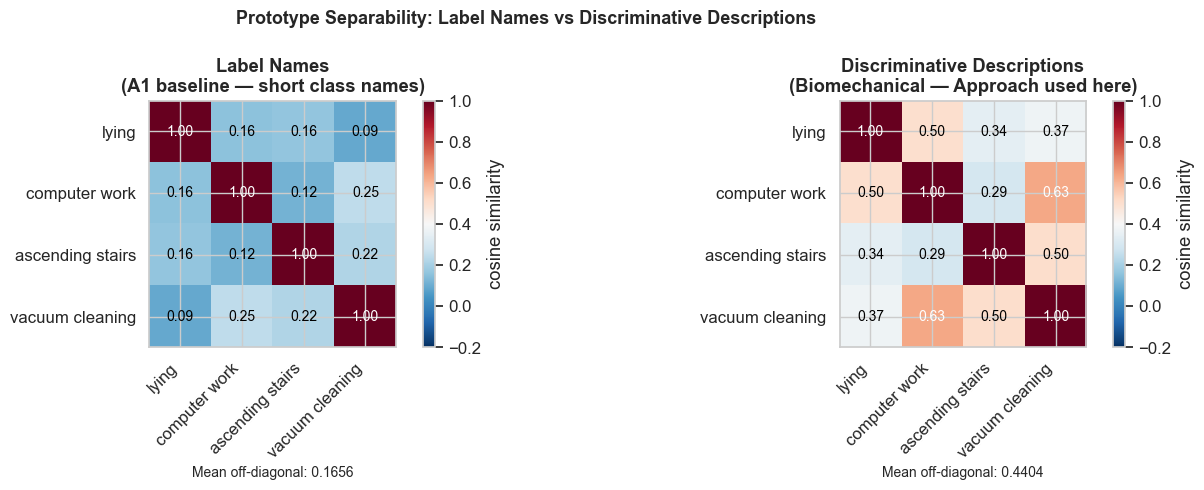

In [134]:
from sentence_transformers import SentenceTransformer

print("Loading Sentence-BERT: all-mpnet-base-v2 ...")
sbert = SentenceTransformer("all-mpnet-base-v2")

class_ids = sorted(ALL_LABELS)
row_idx   = {cid: i for i, cid in enumerate(class_ids)}

# Set A: label names
S_labels = sbert.encode(
    [ACTIVITY_MAP.get(cid, str(cid)) for cid in class_ids],
    normalize_embeddings=True
).astype(np.float32)

# Set B: discriminative descriptions
S_disc = sbert.encode(
    [DISCRIMINATIVE_DESC[cid] for cid in class_ids],
    normalize_embeddings=True
).astype(np.float32)

SEM_DIM    = S_disc.shape[1]
unseen_idx = [row_idx[c] for c in UNSEEN]

def mean_off_diag(M):
    mask = ~np.eye(M.shape[0], dtype=bool)
    return float(M[mask].mean())

sim_labels = S_labels[unseen_idx] @ S_labels[unseen_idx].T
sim_disc   = S_disc[unseen_idx]   @ S_disc[unseen_idx].T

sep_labels = mean_off_diag(sim_labels)
sep_disc   = mean_off_diag(sim_disc)

print(f"\nPrototype separability (mean off-diagonal cosine, unseen classes):")
print(f"  Label names (original A1)          : {sep_labels:.4f}")
print(f"  Discriminative descriptions (this) : {sep_disc:.4f}")
print(f"  Delta                              : {sep_labels - sep_disc:+.4f}")
print(f"  {'IMPROVED' if sep_disc < sep_labels else 'DEGRADED'} vs original")

# Visualisation
names_un = [ACTIVITY_MAP[c] for c in UNSEEN]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, val in zip(
    axes,
    [sim_labels, sim_disc],
    ["Label Names\n(A1 baseline — short class names)",
     "Discriminative Descriptions\n(Biomechanical — Approach used here)"],
    [sep_labels, sep_disc]
):
    im = ax.imshow(mat, vmin=-0.2, vmax=1.0, cmap="RdBu_r")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(len(names_un))); ax.set_xticklabels(names_un, rotation=45, ha="right")
    ax.set_yticks(range(len(names_un))); ax.set_yticklabels(names_un)
    for i in range(len(names_un)):
        for j in range(len(names_un)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=10,
                    color="white" if abs(mat[i,j]) > 0.6 else "black")
    plt.colorbar(im, ax=ax, label="cosine similarity")
    ax.set_xlabel(f"Mean off-diagonal: {val:.4f}", fontsize=10)

fig.suptitle("Prototype Separability: Label Names vs Discriminative Descriptions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "prototype_separability.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# Use discriminative as active prototype set
S   = S_disc.copy()
S_t = torch.tensor(S, dtype=torch.float32)


## 9b. LLM-Generated + Separability-Filtered Prototypes

The hand-crafted discriminative descriptions improved on label names but were
still less separable than plain labels (they share biomechanical vocabulary that
SBERT reads as similarity). Hand-writing can't fix this, because SBERT's geometry
isn't visible from the text — two descriptions that *read* as different can land
close in 768-d space.

This section replaces intuition with optimisation. For each of the 18 classes we
hold a **pool of candidate descriptions** (your original description plus LLM-
generated alternatives that contrast each activity against its near-neighbours).
We then **select one description per class** so that the resulting prototype set
has the lowest possible mean off-diagonal cosine — the exact separability metric
from the paper. Selection is over **all 18 classes** (split-agnostic, and never
tuned to the test classes); the unseen subset becomes more separable as a result.

Because each pool includes the original description, the selected set is
guaranteed to be **at least as separable as the hand-crafted one**.

In [135]:
# ─── Candidate description pool (original + LLM-generated alternatives) ────────
# Each class holds several phrasings emphasising different discriminating axes
# (posture, cadence/frequency, limb involvement, impact, energy). Variety matters:
# different phrasings embed at different points, giving the selector room to find
# a well-separated combination.
EXTRA_DESC = {
    1: [
        "body fully horizontal and supported, no postural muscle activity, breathing the only detectable motion",
        "supine rest with limbs slack, accelerometer dominated by a single steady gravity axis, no dynamic peaks",
        "recumbent stillness, heart rate at resting floor, no step or wrist events across any sensor",
        "horizontal repose, trunk unsupported against gravity, negligible high-frequency content in all channels",
        "complete bodily rest lying down, gyroscope near zero, no orientation change over long spans",
        "stationary horizontal posture, metabolic demand at basal level, absence of impact transients",
        "lying still for extended duration, no voluntary segmental motion, sensor signal flat and low-variance",
        "horizontal body with relaxed musculature, no cyclic pattern, no locomotor signature whatsoever",
        "reclined immobility, occasional slow whole-body roll the only event, otherwise featureless signal",
        "at rest on a flat surface, gravitational acceleration on one dominant axis, motion energy near zero",
        "prone or supine position held continuously, zero translational displacement, sensors near drift",
    ],
    2: [
        "seated upright on a support, weight borne by the pelvis, legs and feet quiescent",
        "static sitting posture, trunk vertical and stable, no gait cycle and no arm swing",
        "chair-bound rest with grounded feet, low movement energy, occasional small torso shift",
        "seated with stationary lower limbs, gravity split between vertical and forward trunk axes, no stepping",
        "upright seated position, minimal wrist motion, no vertical bounce, low metabolic cost",
        "sitting quietly, hips flexed and knees bent at rest, no periodic acceleration",
        "seated stillness distinct from lying by a vertical trunk orientation, limbs unloaded",
        "bench or chair sitting, no translational movement, trunk axis upright, low variance",
        "resting in a seated posture, infrequent posture adjustments, no foot-contact impacts",
        "stationary seated body, lower-leg sensors idle, hand sensor near baseline",
        "sitting with settled posture, no locomotion, energy expenditure just above lying",
    ],
    3: [
        "upright standing still, continuous small ankle and hip balance corrections, no forward travel",
        "bipedal stance held in place, slow postural sway under one hertz, no step events",
        "stationary standing, full body weight on both feet, trunk vertical, no translational displacement",
        "erect motionless posture distinguished from walking by absence of stride periodicity",
        "standing balance with subtle center-of-mass micro-adjustments, no arm pendulum",
        "vertical stance, feet planted, only low-frequency wobble in gyroscope, no gait rhythm",
        "standing in one spot, gravity aligned to the vertical axis, negligible high-frequency motion",
        "upright still posture, leg muscles tonically active for balance, no cyclic foot impacts",
        "motionless on two feet, occasional weight shift between legs, no locomotor cadence",
        "quiet standing, signal dominated by slow sway rather than periodic stepping",
        "stationary upright body, no displacement, distinguished from sitting by loaded extended legs",
    ],
    4: [
        "steady ground-level walking, alternating foot strikes near two hertz, gentle arm swinging",
        "regular gait with heel-strike and toe-off, moderate vertical bounce, comfortable pace",
        "bipedal locomotion at walking cadence, each foot contacting ground without flight phase",
        "level-ground ambulation, periodic acceleration peaks at footfall, smooth forward travel",
        "ordinary walking rhythm, pendular arm motion synchronized to the opposite leg, low impact",
        "continuous stepping at a relaxed tempo, double-support phase present, no aerial phase",
        "forward walking with consistent stride period, mild cardiovascular load",
        "ground contact maintained throughout, cadence around 110 steps per minute, even rhythm",
        "walking on flat terrain, alternating limb swing, moderate energy, no pole or rope involvement",
        "natural gait cycle repeating about every half second, balanced vertical oscillation",
        "steady-paced walk distinguished from running by retained ground contact and lower peaks",
    ],
    5: [
        "running with a flight phase where both feet leave the ground between strikes",
        "high-tempo locomotion near three hertz, sharp impact spikes at each footstrike",
        "sustained run, large vertical acceleration peaks exceeding four g, elevated heart rate",
        "fast cyclic gait with airborne intervals, forceful toe-off propulsion",
        "jogging to sprinting motion, impulsive ankle loading, high metabolic demand",
        "running cadence with brief double-float, strong rhythmic acceleration, heavy breathing load",
        "rapid forward running, ground contact short and percussive, peak forces well above walking",
        "continuous run distinguished from walking by aerial phase and amplitude of impact",
        "high-energy bipedal running, stride frequency high, near-maximal sustainable output",
        "powerful repetitive footstrikes with flight, large oscillation at trunk and ankle",
        "endurance running motion, periodic high-g landings, sustained elevated pulse",
    ],
    6: [
        "pedalling a bicycle with smooth circular leg rotation, upper body seated and steady",
        "cyclic knee extension and flexion near eighty rpm, no footstrike impacts at all",
        "seated cycling, legs drive continuous rotation, trunk relatively fixed over the frame",
        "rotary lower-limb motion without ground contact transients, steady cadence",
        "bicycling effort, alternating downward leg thrust, absence of heel-strike spikes",
        "cycling with hands on bars and torso braced, rhythmic pedal-driven knee cycling",
        "continuous pedal revolutions, no vertical body bounce, sustained aerobic effort",
        "leg-powered rotation distinguished from walking by lack of impact and fixed seated trunk",
        "stationary or road cycling, smooth periodic leg signal, low upper-body movement",
        "pedalling motion, knee angle oscillating smoothly, no foot-ground collision",
        "cycling cadence steady, energy in the lower limbs, trunk and arms quiet",
    ],
    7: [
        "walking with poles, each stride accompanied by a synchronized pole plant on the opposite side",
        "pole-assisted walking, elevated arm and shoulder engagement, contact at both feet and poles",
        "Nordic technique combining a walking gait with rhythmic bilateral arm driving",
        "fitness walking with sticks, upper limbs load-bearing, larger arm range than ordinary walking",
        "striding with poles, dual impact sources from feet and pole tips, raised elbow motion",
        "walking cadence augmented by active pole pushes, stronger forearm and shoulder signal",
        "Nordic walking distinguished from plain walking by upper-limb load and pole strikes",
        "pole walking with a coordinated four-contact pattern, moderate pace, engaged triceps",
        "ambulation with trekking poles, periodic arm thrust adding propulsion",
        "walking enhanced by poles, wrist and elbow more active than in unaided gait",
        "Nordic stride with rhythmic alternating pole strikes and elevated arm acceleration",
    ],
    9: [
        "sitting passively in front of a screen, almost no voluntary movement for long stretches",
        "leisure rest watching a display, rare slow shifts in posture, very low energy",
        "extended sedentary viewing, body relaxed and still, sensors near baseline",
        "passive screen watching, occasional minor limb repositioning, no task-driven hand motion",
        "quiet seated leisure, metabolic rate minimal, no periodic or purposeful movement",
        "reclined or seated viewing, long motionless intervals broken by infrequent fidget",
        "watching television distinguished from computer work by absence of repetitive hand input",
        "sedentary relaxation facing forward, negligible wrist activity, low overall variance",
        "prolonged stillness during viewing, only slow comfort adjustments detected",
        "couch-bound leisure, no locomotion, no manipulation, signal flat and quiet",
        "screen-directed rest, body settled, energy expenditure close to sitting at rest",
    ],
    10: [
        "seated at a desk performing typing and mouse work, frequent small hand movements",
        "fine motor finger and wrist activity at a keyboard, torso held still, legs idle",
        "office work with repetitive low-amplitude hand motion, no whole-body displacement",
        "desk-based task, wrist flexion and extension below one hertz, dominant hand-sensor signal",
        "seated computer use, purposeful intermittent hand input, lower body quiescent",
        "keyboard and pointer activity, small bursts of wrist motion, stationary trunk",
        "computer work distinguished from watching by recurring task-driven hand micro-movements",
        "deskwork with hands active and the body otherwise still, low leg involvement",
        "typing rhythm in the hand sensor, irregular short movements, no gait or impact",
        "seated productivity task, fine manipulation at the wrist, negligible vertical motion",
        "screen-and-keyboard work, hand-dominant low-frequency activity, torso fixed",
    ],
    11: [
        "seated in a moving vehicle, road vibration transmitted broadly, small steering hand corrections",
        "driving posture with continuous low-level chassis vibration, occasional wrist steering input",
        "operating a car, body passively shaken by the road, voluntary motion limited to controls",
        "vehicle driving, broadband vibration signature distinct from voluntary movement",
        "seated control of a car, subtle periodic steering motions, ambient engine and road vibration",
        "in-car driving, whole-body passive vibration, low purposeful movement aside from steering",
        "driving distinguished from sitting by superimposed road-induced vibration across sensors",
        "behind the wheel, hands making small steering corrections, body coupled to vehicle motion",
        "automobile operation, faint continuous vibration plus intermittent wrist steering events",
        "seated driving with an engine-vibration baseline, occasional control-limb movement",
        "car travel as the driver, passive trunk vibration, minimal voluntary limb dynamics",
    ],
    12: [
        "climbing stairs upward, each step lifting the body, forward trunk lean, propulsive toe push",
        "stair ascent with concentric leg effort, altitude rising step by step",
        "going up steps, vertical body displacement upward per cycle, increased quadriceps load",
        "upward staircase climbing, forward-leaning posture, push-off propelling the body higher",
        "ascending steps, periodic upward lift, heart rate climbing, distinct from level walking",
        "stair-up locomotion, leg extension raising body mass against gravity each step",
        "climbing upward with net altitude gain, forward lean and a strong push-off phase",
        "stepping up a staircase, upward vertical work, concentric muscle action",
        "ascent on stairs distinguished from descent by upward displacement and lifting effort",
        "uphill stair motion, body rising, propulsive toe-off, increasing elevation",
        "going upstairs, rhythmic upward steps, elevated effort versus flat walking",
    ],
    13: [
        "walking down stairs, body lowering each step, eccentric braking at the knees",
        "stair descent with controlled downward displacement, heel-first landings, deceleration impacts",
        "going down steps, net altitude loss, backward trunk lean for balance",
        "downward staircase motion, braking forces at each footfall, body descending",
        "descending steps, eccentric quadriceps control absorbing impact, downward travel",
        "stair-down locomotion, controlled drop per step, distinct deceleration spikes",
        "going downstairs, body sinking step by step, the knee acting as a brake",
        "downhill stair motion distinguished from ascent by descending displacement and braking",
        "stepping down a staircase, repeated controlled landings, altitude decreasing",
        "descent on stairs, heel-strike braking, backward lean, downward vertical work",
        "downward stepping, eccentric loading, deceleration at every contact",
    ],
    16: [
        "pushing and pulling a vacuum across the floor while shuffling slowly back and forth",
        "cleaning with a vacuum, repetitive arm push-pull strokes combined with slow ambulation",
        "vacuuming with dominant forward-backward wrist motion plus intermittent stepping and bending",
        "floor cleaning with an appliance, mixed slow walking and rhythmic arm extension-retraction",
        "operating a vacuum, trunk bending toward the floor, bilateral push and pull at the hands",
        "vacuum task blending locomotion and arm manipulation at an irregular slow pace",
        "back-and-forth vacuuming strokes, hand-dominant push-pull, occasional reach and bend",
        "cleaning floors with a vacuum, arm sweeping motion with sporadic foot repositioning",
        "vacuum cleaning distinguished by combined slow gait and repetitive appliance pushing",
        "household vacuuming with wrist push-pull cycles, low-speed shuffling, trunk flexion",
        "pushing a vacuum head forward and back, mixed manipulation and locomotion signal",
    ],
    17: [
        "ironing while standing, smooth single-arm gliding strokes over a board",
        "pressing garments with low-frequency back-and-forth arm motion, feet mostly planted",
        "standing ironing task, dominant hand sweeping slowly, occasional weight shift between feet",
        "smooth repetitive arm glide of an iron, no locomotion, trunk fairly still",
        "ironing clothes with single-arm low-speed strokes under one hertz, standing in place",
        "garment pressing, gentle gliding wrist motion, minimal lower-body movement",
        "standing and ironing, rhythmic but slow forearm sweeps, no stepping",
        "ironing distinguished from vacuuming by smoother single-arm strokes and no gait",
        "pressing fabric with an iron, steady arm motion, body stationary",
        "ironing posture with dominant-hand gliding, slow cadence, subtle weight transfer",
        "standing fabric-pressing, smooth low-amplitude arm motion, no floor travel",
    ],
    18: [
        "folding clothes while standing, both hands manipulating fabric with frequent direction changes",
        "laundry folding with symmetric bilateral arm motion, repeated wrist reversals, no walking",
        "standing and folding garments, hands working together, no lower-body locomotion",
        "fabric folding task, two-handed manipulation, frequent short arm movements in place",
        "folding washing, bilateral hand activity with reversing motions, stationary feet",
        "garment folding with symmetric arm gestures, no gait and no impact",
        "standing laundry folding distinguished by two-handed reversing manipulation without travel",
        "folding clothes with coordinated hand movements, trunk upright and still",
        "manual folding of garments, repetitive bidirectional wrist motion, no stepping",
        "two-handed fabric folding, frequent motion reversals, body stationary",
        "standing folding task, bilateral arm work, low-amplitude reversing hand motion",
    ],
    19: [
        "general house cleaning combining walking with wiping, reaching, and bending",
        "tidying tasks with irregular stepping mixed with arm reaching and trunk rotation",
        "cleaning around a home, varied motion of locomotion plus sporadic manipulation",
        "housework with mixed-frequency activity, bending and reaching during intermittent walking",
        "domestic cleaning, irregular gait interleaved with wiping and stretching motions",
        "house tidying, an unpredictable blend of steps, reaches, and bends",
        "cleaning chores combining ambulation and upper-body manipulation, no steady rhythm",
        "household cleaning distinguished by an irregular mixed locomotion-and-reach pattern",
        "moving about while wiping surfaces and bending, variable cadence",
        "general cleaning with trunk rotation and reaching during stop-start walking",
        "home cleaning activity, heterogeneous motion with no fixed periodicity",
    ],
    20: [
        "playing soccer with sprint bursts, sudden direction changes, and ball kicks",
        "football activity with explosive accelerations, lateral cuts, and impulsive kicking at the foot",
        "soccer play, unpredictable high accelerations interleaved with sprints and stops",
        "game movement with rapid lateral shuffles, kicks, and maximal-effort runs",
        "soccer with intermittent sprinting and cutting, sharp foot impulses from kicking",
        "playing football, high-variance acceleration, sudden starts, stops, and direction reversals",
        "soccer match motion distinguished by erratic explosive bursts and kicking impacts",
        "field-sport play, rapid changes of pace and direction, peak cardiovascular output",
        "soccer activity with a sprint-cut-kick pattern, unpredictable high-magnitude acceleration",
        "playing soccer, bursts of running with lateral agility and ball strikes",
        "competitive soccer movement, irregular explosive efforts and foot kicking impulses",
    ],
    24: [
        "skipping rope with rapid two-footed jumps near two and a half hertz",
        "jump rope with symmetric vertical hops synchronized to wrist rope rotation",
        "rope skipping, high-cadence bilateral jumping, full body lift each cycle",
        "jumping rope, repetitive vertical displacement with rhythmic wrist circling",
        "skipping with fast symmetric two-foot bounces at near-maximal effort",
        "rope jumping, periodic high vertical acceleration plus continuous wrist rotation",
        "jump-rope motion distinguished by very high cadence vertical hops and wrist spin",
        "skipping rope, both feet leaving and landing together at high frequency",
        "rope-skipping exercise, strong rhythmic vertical bounce, wrists rotating the rope",
        "high-tempo rope jumping with symmetric landings and sustained intense effort",
        "jumping rope, regular vertical oscillation with coordinated wrist rope turns",
    ],
}

# Build the pool: the ORIGINAL discriminative description is candidate index 0 for
# every class, which guarantees the selected set can only match or beat it.
CANDIDATE_DESC = {cid: [DISCRIMINATIVE_DESC[cid]] + EXTRA_DESC[cid] for cid in ACTIVITY_MAP}
assert set(EXTRA_DESC) == set(ACTIVITY_MAP), "candidate keys must cover all classes"
print("Candidate pool built:")
for cid in class_ids:
    print(f"  {ACTIVITY_MAP[cid]:<20} {len(CANDIDATE_DESC[cid]):>2} candidates (incl. original)")

Candidate pool built:
  lying                12 candidates (incl. original)
  sitting              12 candidates (incl. original)
  standing             12 candidates (incl. original)
  walking              12 candidates (incl. original)
  running              12 candidates (incl. original)
  cycling              12 candidates (incl. original)
  Nordic walking       12 candidates (incl. original)
  watching TV          12 candidates (incl. original)
  computer work        12 candidates (incl. original)
  car driving          12 candidates (incl. original)
  ascending stairs     12 candidates (incl. original)
  descending stairs    12 candidates (incl. original)
  vacuum cleaning      12 candidates (incl. original)
  ironing              12 candidates (incl. original)
  folding laundry      12 candidates (incl. original)
  house cleaning       12 candidates (incl. original)
  playing soccer       12 candidates (incl. original)
  rope jumping         12 candidates (incl. original)


### Selection by separability-minimising coordinate descent

We encode every candidate with the same SBERT model, then choose one description
per class to minimise the mean off-diagonal cosine of the 18 prototypes. The
search space is huge, so we use **coordinate descent**: repeatedly sweep the
classes, and for each one swap in whichever candidate is *least* similar to the
currently-selected prototypes of all other classes. This monotonically reduces
the objective and converges to a local optimum; we run several random restarts
plus one restart initialised from the original descriptions, and keep the best.

The candidate whose phrasing *reads* most distinctive is often not the one that
*embeds* most distinctively — which is exactly why this is done against the cosine
matrix rather than by hand. Set `USE_LLM_PROTOTYPES = False` to revert to the
hand-crafted set for an A/B comparison.

In [136]:
# ─── Encode candidate pool ────────────────────────────────────────────────────
USE_LLM_PROTOTYPES = True          # set False to keep the hand-written discriminative set
N_RESTARTS         = 12            # random restarts for coordinate descent
SEL_RNG            = np.random.RandomState(SEED)

cand_emb = {cid: sbert.encode(CANDIDATE_DESC[cid], normalize_embeddings=True).astype(np.float32)
            for cid in class_ids}

# ─── Separability objective + coordinate-descent selection ────────────────────
def _stacked(sel):
    return np.stack([cand_emb[cid][sel[cid]] for cid in class_ids], axis=0)

def _objective(sel):
    M = _stacked(sel)
    return mean_off_diag(M @ M.T)

def _coordinate_descent(sel, max_sweeps=100):
    sel = dict(sel)
    for _ in range(max_sweeps):
        changed = False
        order = list(class_ids); SEL_RNG.shuffle(order)
        for cid in order:
            others    = np.stack([cand_emb[c][sel[c]] for c in class_ids if c != cid], axis=0)
            mean_sims = (cand_emb[cid] @ others.T).mean(axis=1)   # sim of each candidate to all other protos
            k = int(np.argmin(mean_sims))
            if k != sel[cid]:
                sel[cid] = k; changed = True
        if not changed:
            break
    return sel

# restart 0: start from the ORIGINAL descriptions (index 0) -> result is guaranteed <= original
orig_sel = {cid: 0 for cid in class_ids}
best_sel = _coordinate_descent(orig_sel)
best_obj = _objective(best_sel)
for _ in range(1, N_RESTARTS):
    rand_sel = {cid: SEL_RNG.randint(len(CANDIDATE_DESC[cid])) for cid in class_ids}
    cand_sel = _coordinate_descent(rand_sel)
    obj      = _objective(cand_sel)
    if obj < best_obj:
        best_obj, best_sel = obj, cand_sel

LLM_DESC = {cid: CANDIDATE_DESC[cid][best_sel[cid]] for cid in class_ids}
S_llm    = _stacked(best_sel)

# ─── Report separability: all 18 classes + the current unseen subset ──────────
unseen_pos = [row_idx[c] for c in UNSEEN]
def _report(name, vecs):
    M = vecs @ vecs.T
    sub = mean_off_diag(M[np.ix_(unseen_pos, unseen_pos)])
    print(f"  {name:<34} all-18: {mean_off_diag(M):.4f}   unseen-subset: {sub:.4f}")

print("Prototype separability (mean off-diagonal cosine; lower = more separable)")
_report("Label names", S_labels)
_report("Hand-crafted discriminative", S_disc)
_report("LLM-generated + filtered (this)", S_llm)
print(f"\nObjective (all-18)  original -> selected : {_objective(orig_sel):.4f} -> {best_obj:.4f}")

# ─── Activate the selected prototypes for all downstream training & inference ──
if USE_LLM_PROTOTYPES:
    S   = S_llm.copy()
    S_t = torch.tensor(S, dtype=torch.float32)
    print("\nActive prototype set -> LLM-generated + separability-filtered.")
else:
    print("\nUSE_LLM_PROTOTYPES = False -> keeping hand-crafted discriminative set.")

n_changed = sum(best_sel[cid] != 0 for cid in class_ids)
print(f"Classes whose description changed from the original: {n_changed}/18")

Prototype separability (mean off-diagonal cosine; lower = more separable)
  Label names                        all-18: 0.3101   unseen-subset: 0.1656
  Hand-crafted discriminative        all-18: 0.4526   unseen-subset: 0.4404
  LLM-generated + filtered (this)    all-18: 0.2001   unseen-subset: 0.1681

Objective (all-18)  original -> selected : 0.4526 -> 0.2001

Active prototype set -> LLM-generated + separability-filtered.
Classes whose description changed from the original: 17/18


### Separability comparison

How the selected set compares to label names and the hand-crafted descriptions,
on all 18 classes and on the current unseen subset. The target is to land at or
below the label-name bar — descriptive *and* well-separated.

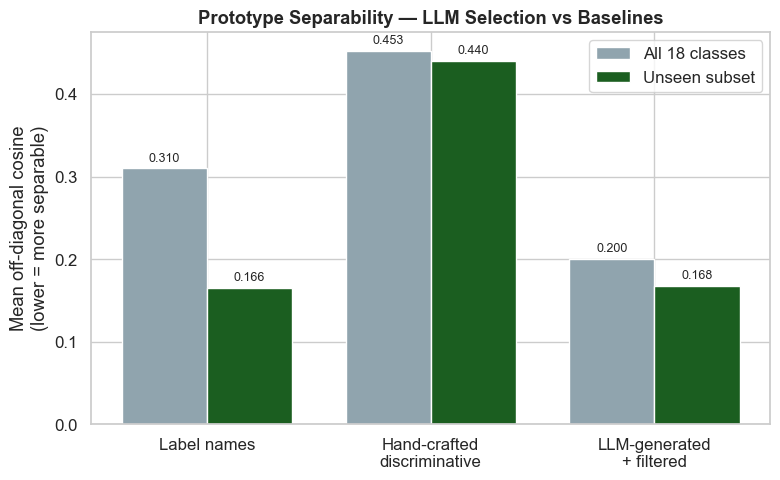

Saved: prototype_separability_llm.png


In [137]:
# ─── Visualisation: prototype separability — LLM selection vs baselines ───────
methods = ["Label names", "Hand-crafted\ndiscriminative", "LLM-generated\n+ filtered"]
mats    = [S_labels, S_disc, S_llm]
all18    = [mean_off_diag(M @ M.T) for M in mats]
unseen_v = [mean_off_diag((M @ M.T)[np.ix_(unseen_pos, unseen_pos)]) for M in mats]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(methods)); w = 0.38
b1 = ax.bar(x - w/2, all18,    w, label="All 18 classes", color="#90A4AE", edgecolor="white")
b2 = ax.bar(x + w/2, unseen_v, w, label="Unseen subset",  color="#1B5E20", edgecolor="white")
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel("Mean off-diagonal cosine\n(lower = more separable)")
ax.set_title("Prototype Separability — LLM Selection vs Baselines", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "prototype_separability_llm.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: prototype_separability_llm.png")

## 9c. Attribute Prototypes (alternative semantic space)

Hand-designed attribute vectors in place of sentence embeddings, following the
attribute-based zero-shot formulation (Cheng et al., MobiSys 2013; Lampert et al.,
TPAMI 2014). Set `USE_ATTRIBUTES = True` to make these the active prototype set;
everything downstream picks up the new `S`, `S_t` and `SEM_DIM` unchanged.


In [138]:
# ─── Attribute prototype space (NuActiv-style) ───────────────────────────────
# An alternative semantic space to SBERT text. Attributes are orthogonal by
# construction, which is what the coordinate-descent selection above tries to
# approximate through description choice. The signed `vertical` dimension is the
# key one: ascending stairs (+1) and descending stairs (-1) become maximally
# separated, which no amount of SBERT prose achieves.
#
# The values below are a STARTING DRAFT and should be revised against the actual
# signals before being reported.

USE_ATTRIBUTES = False     # True -> replace the active prototype set with attributes
ATTR_CENTER    = True      # column-centre before L2 normalising. Raw attribute rows are
                           # almost all non-negative, so every pair has high cosine
                           # (unseen-subset 0.667). Centring removes that shared offset
                           # (unseen-subset 0.013) without changing the relative geometry.

ATTR_NAMES = ["lying", "sitting", "upright", "locomotion", "vertical", "cadence",
              "impact", "arm_motion", "leg_motion", "periodicity", "intensity",
              "object_manip", "trunk_flexion", "static_load", "vehicle_vibration"]

ATTRS = {
    #        lie  sit  upr  loco vert cad  imp  arm  leg  per  int  obj  trnk stat veh
    1:  [1.0, 0.0, 0.0, 0.0,  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # lying
    2:  [0.0, 1.0, 0.0, 0.0,  0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.1, 0.0, 0.0, 0.2, 0.0],  # sitting
    3:  [0.0, 0.0, 1.0, 0.0,  0.0, 0.1, 0.0, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.4, 0.0],  # standing
    4:  [0.0, 0.0, 1.0, 1.0,  0.0, 0.6, 0.5, 0.5, 1.0, 1.0, 0.5, 0.0, 0.1, 0.0, 0.0],  # walking
    5:  [0.0, 0.0, 1.0, 1.0,  0.0, 0.9, 1.0, 0.7, 1.0, 1.0, 1.0, 0.0, 0.1, 0.0, 0.0],  # running
    6:  [0.0, 1.0, 0.0, 1.0,  0.0, 0.7, 0.0, 0.1, 1.0, 1.0, 0.7, 0.0, 0.2, 0.3, 0.0],  # cycling
    7:  [0.0, 0.0, 1.0, 1.0,  0.0, 0.6, 0.5, 1.0, 1.0, 1.0, 0.7, 1.0, 0.1, 0.0, 0.0],  # Nordic walking
    9:  [0.0, 1.0, 0.0, 0.0,  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0],  # watching TV
    10: [0.0, 1.0, 0.0, 0.0,  0.0, 0.1, 0.0, 0.5, 0.0, 0.1, 0.1, 0.5, 0.0, 0.3, 0.0],  # computer work
    11: [0.0, 1.0, 0.0, 0.0,  0.0, 0.0, 0.0, 0.3, 0.0, 0.0, 0.1, 0.3, 0.0, 0.4, 1.0],  # car driving
    12: [0.0, 0.0, 1.0, 1.0,  1.0, 0.5, 0.5, 0.3, 1.0, 0.9, 0.7, 0.0, 0.2, 0.0, 0.0],  # ascending stairs
    13: [0.0, 0.0, 1.0, 1.0, -1.0, 0.5, 0.7, 0.3, 1.0, 0.9, 0.5, 0.0, 0.2, 0.0, 0.0],  # descending stairs
    16: [0.0, 0.0, 1.0, 0.4,  0.0, 0.3, 0.1, 0.9, 0.4, 0.6, 0.4, 1.0, 0.5, 0.3, 0.0],  # vacuum cleaning
    17: [0.0, 0.0, 1.0, 0.0,  0.0, 0.3, 0.0, 0.9, 0.1, 0.7, 0.2, 1.0, 0.1, 0.8, 0.0],  # ironing
    18: [0.0, 0.0, 1.0, 0.0,  0.0, 0.2, 0.0, 1.0, 0.0, 0.3, 0.2, 1.0, 0.3, 0.6, 0.0],  # folding laundry
    19: [0.0, 0.0, 1.0, 0.6,  0.0, 0.4, 0.2, 0.9, 0.5, 0.3, 0.5, 1.0, 0.6, 0.2, 0.0],  # house cleaning
    20: [0.0, 0.0, 1.0, 1.0,  0.0, 0.9, 1.0, 0.6, 1.0, 0.3, 1.0, 0.3, 0.3, 0.0, 0.0],  # playing soccer
    24: [0.0, 0.0, 1.0, 0.0,  0.0, 1.0, 1.0, 0.8, 1.0, 1.0, 1.0, 0.5, 0.0, 0.0, 0.0],  # rope jumping
}

assert set(ATTRS.keys()) == set(ACTIVITY_MAP.keys()), "attribute rows must cover all 18 classes"
assert all(len(v) == len(ATTR_NAMES) for v in ATTRS.values()), "attribute row length mismatch"

S_attr = np.stack([np.array(ATTRS[cid], dtype=np.float32) for cid in class_ids], axis=0)
if ATTR_CENTER:
    S_attr = S_attr - S_attr.mean(axis=0, keepdims=True)
S_attr = S_attr / np.linalg.norm(S_attr, axis=1, keepdims=True)

_M_attr = S_attr @ S_attr.T
print("Attribute prototype separability (mean off-diagonal cosine; lower = better)")
print(f"  Attributes ({len(ATTR_NAMES)}-d, centred={ATTR_CENTER})     "
      f"all-18: {mean_off_diag(_M_attr):.4f}   "
      f"unseen-subset: {mean_off_diag(_M_attr[np.ix_(unseen_pos, unseen_pos)]):.4f}")

if USE_ATTRIBUTES:
    S       = S_attr.copy()
    S_t     = torch.tensor(S, dtype=torch.float32)
    SEM_DIM = S.shape[1]
    print(f"\nActive prototype set -> attributes ({SEM_DIM}-d).")
    print("Reminder: TEMP=0.07 was tuned for 768-d text embeddings. Sweep "
          "{0.07, 0.1, 0.2} on the val-unseen classes for this space.")
else:
    print("\nUSE_ATTRIBUTES = False -> keeping the active text prototype set.")


Attribute prototype separability (mean off-diagonal cosine; lower = better)
  Attributes (15-d, centred=True)     all-18: -0.0550   unseen-subset: -0.1886

USE_ATTRIBUTES = False -> keeping the active text prototype set.


## 10. TCN Sensor Encoder

Three dilated residual TCN blocks (channels 64/96/128, dilations 1/2/4, kernel 5) + global average pooling + a 128→512→768 projection head, L2-normalised. ~0.73M parameters. The architecture is fixed; only the training objective and prototypes vary.

In [139]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, d=1, dropout=0.2):
        super().__init__()
        pad = (k - 1) * d // 2
        self.net = nn.Sequential(
            nn.Conv1d(in_ch,  out_ch, k, dilation=d, padding=pad),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, k, dilation=d, padding=pad),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
        )
        self.res = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.res(x)


class TCNEncoder(nn.Module):
    def __init__(self, n_features, channels=(64,96,128), k=5, dropout=0.2):
        super().__init__()
        blocks, in_ch, d = [], n_features, 1
        for out_ch in channels:
            blocks.append(TCNBlock(in_ch, out_ch, k=k, d=d, dropout=dropout))
            in_ch = out_ch; d *= 2
        self.tcn = nn.Sequential(*blocks)

    def forward(self, x):
        x = x.transpose(1, 2)
        return self.tcn(x).mean(dim=2)


class ZSLModel(nn.Module):
    def __init__(self, n_features, emb_dim,
                 enc_channels=(64,96,128), proj=512, dropout=0.2):
        super().__init__()
        self.enc  = TCNEncoder(n_features, channels=enc_channels, k=5, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(enc_channels[-1], proj), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj, emb_dim),
        )

    def forward(self, x):
        z = self.head(self.enc(x))
        return z / (z.norm(dim=1, keepdim=True) + 1e-8)


N_FEATURES = X_tr_n.shape[-1]
model      = ZSLModel(n_features=N_FEATURES, emb_dim=SEM_DIM)
print(f"Model parameters : {sum(p.numel() for p in model.parameters())/1e6:.2f} M")
print(f"Output emb dim   : {SEM_DIM}")


Model parameters : 0.73 M
Output emb dim   : 768


## 11. Contrastive Semantic Training

The encoder is trained with cross-entropy over cosine similarities to the **seen-class** prototypes only (temperature 0.07) — the IMU analogue of CLIP-style alignment. This is what closes the modality gap at its source. Restricting the softmax denominator to seen classes matters: with all 18 prototypes in the denominator, the unseen prototypes appear only ever as negatives and are actively pushed away from the sensor embeddings. Set `SEEN_ONLY_SOFTMAX = False` to reproduce the 18-way version. The best checkpoint on validation seen-class accuracy is restored in the following cell.

In [140]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH_SIZE = 128

train_loader = DataLoader(WindowDataset(X_tr_n, y_tr),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(WindowDataset(X_val_n, y_val),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(WindowDataset(X_test_u_n, y_test_u),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
valu_loader  = DataLoader(WindowDataset(X_valu_n, y_valu),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

DEVICE_FINAL = DEVICE
model        = model.to(DEVICE_FINAL)
S_t          = S_t.to(DEVICE_FINAL)

# ─── Seen-only softmax denominator ────────────────────────────────────────────
# The unseen prototypes must not appear in the training denominator: they can
# never be a positive target, so including them means the encoder is optimised
# to push sensor embeddings AWAY from exactly the prototypes it will be matched
# against at inference time.
SEEN_ONLY_SOFTMAX = True     # False -> original 18-way denominator

seen_rows = torch.tensor([row_idx[c] for c in SEEN], device=DEVICE_FINAL)
S_seen    = S_t[seen_rows]                       # (|SEEN|, SEM_DIM)
seen_pos  = {c: i for i, c in enumerate(SEEN)}   # class id -> row of S_seen

EPOCHS    = 40
LR        = 1e-3
TEMP      = 0.07
PATIENCE  = 15
MIN_DELTA = 1e-4

optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)

best_val_acc = 0.0
best_state   = None
bad_epochs   = 0
history      = {"train_loss": [], "val_seen_acc": []}

print(f"Training | denominator={'seen-only' if SEEN_ONLY_SOFTMAX else 'all-18'} "
      f"({len(SEEN) if SEEN_ONLY_SOFTMAX else len(class_ids)} prototypes) | τ={TEMP} | LR={LR}\n")

for ep in range(1, EPOCHS + 1):
    model.train()
    running, n = 0.0, 0
    for xb, yb in train_loader:
        xb  = xb.to(DEVICE_FINAL)
        if SEEN_ONLY_SOFTMAX:
            tgt = torch.tensor([seen_pos[int(l)] for l in yb.numpy()],
                               device=DEVICE_FINAL, dtype=torch.long)
            P_train = S_seen
        else:
            tgt = torch.tensor([row_idx[int(l)] for l in yb.numpy()],
                               device=DEVICE_FINAL, dtype=torch.long)
            P_train = S_t
        e      = model(xb)
        logits = (e @ P_train.T) / TEMP
        loss   = nn.functional.cross_entropy(logits, tgt)
        optimiser.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        running += float(loss.item()) * len(xb); n += len(xb)

    train_loss = running / max(n, 1)

    # Validation: nearest-prototype on seen classes
    model.eval()
    cand_idx = torch.tensor([row_idx[c] for c in SEEN], device=DEVICE_FINAL)
    proto_v  = S_t[cand_idx]
    yt_v, yp_v = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            e = model(xb.to(DEVICE_FINAL))
            k = (e @ proto_v.T).argmax(dim=1).cpu().numpy()
            yt_v.append(yb.numpy())
            yp_v.append(np.array([SEEN[i] for i in k], dtype=np.int64))
    val_acc = float((np.concatenate(yt_v) == np.concatenate(yp_v)).mean())

    scheduler.step()
    history["train_loss"].append(train_loss)
    history["val_seen_acc"].append(val_acc)
    print(f"Epoch {ep:02d}/{EPOCHS}  |  loss={train_loss:.4f}  |  val_seen_acc={val_acc:.3f}")

    if val_acc > best_val_acc + MIN_DELTA:
        best_val_acc = val_acc
        best_state   = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        bad_epochs   = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"\nEarly stop at epoch {ep}. Best val acc: {best_val_acc:.3f}"); break

# NOTE: checkpoint restore lives in the NEXT cell, so that an interrupted
# training run can still be recovered by running that cell manually.


Training | denominator=seen-only (12 prototypes) | τ=0.07 | LR=0.001

Epoch 01/40  |  loss=0.3937  |  val_seen_acc=0.972
Epoch 02/40  |  loss=0.0773  |  val_seen_acc=0.992
Epoch 03/40  |  loss=0.0521  |  val_seen_acc=0.994
Epoch 04/40  |  loss=0.0368  |  val_seen_acc=0.999
Epoch 05/40  |  loss=0.0359  |  val_seen_acc=0.995
Epoch 06/40  |  loss=0.0177  |  val_seen_acc=0.996
Epoch 07/40  |  loss=0.0136  |  val_seen_acc=0.995
Epoch 08/40  |  loss=0.0136  |  val_seen_acc=0.995
Epoch 09/40  |  loss=0.0102  |  val_seen_acc=0.995
Epoch 10/40  |  loss=0.0110  |  val_seen_acc=0.999
Epoch 11/40  |  loss=0.0085  |  val_seen_acc=0.999
Epoch 12/40  |  loss=0.0039  |  val_seen_acc=0.995
Epoch 13/40  |  loss=0.0062  |  val_seen_acc=0.999
Epoch 14/40  |  loss=0.0032  |  val_seen_acc=0.996
Epoch 15/40  |  loss=0.0032  |  val_seen_acc=0.992
Epoch 16/40  |  loss=0.0028  |  val_seen_acc=0.999
Epoch 17/40  |  loss=0.0045  |  val_seen_acc=0.999
Epoch 18/40  |  loss=0.0026  |  val_seen_acc=0.999
Epoch 19/40 

In [141]:
# ─── Restore best checkpoint ─────────────────────────────────────────────────
# Kept in its own cell so that an interrupted training run (KeyboardInterrupt in
# the cell above aborts before any trailing statement) can still be recovered by
# running this cell manually.
if best_state:
    model.load_state_dict({k: v.to(DEVICE_FINAL) for k, v in best_state.items()})
    print(f"Best checkpoint restored (val seen acc {best_val_acc:.3f}).")
else:
    print("WARNING: no best_state saved — model still holds the live weights.")


Best checkpoint restored (val seen acc 0.999).


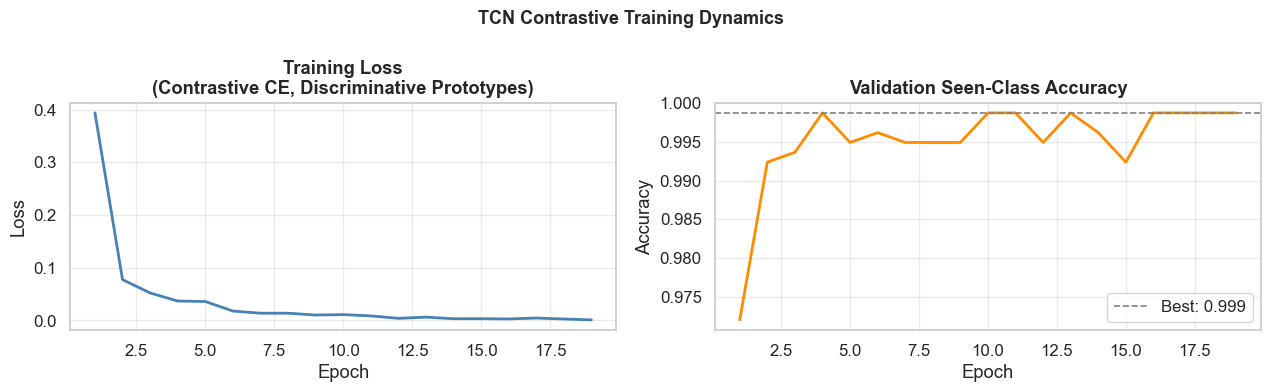

In [142]:
# Training curves
epochs_ran = len(history["train_loss"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(range(1, epochs_ran+1), history["train_loss"], color="steelblue", linewidth=2)
ax1.set_title("Training Loss\n(Contrastive CE, Discriminative Prototypes)", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(True, alpha=0.4)

ax2.plot(range(1, epochs_ran+1), history["val_seen_acc"], color="darkorange", linewidth=2)
ax2.axhline(best_val_acc, color="gray", linestyle="--", linewidth=1.2,
            label=f"Best: {best_val_acc:.3f}")
ax2.set_title("Validation Seen-Class Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle("TCN Contrastive Training Dynamics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()


## 12. Test Embeddings & Modality Gap

Encode the unseen test windows and the seen-class sensor centroids, then measure the mean text-sensor cosine — a direct read of how well contrastive training aligned the two modalities (vs ~0.30 for the label-name baseline).

In [143]:
# ─── Collect test embeddings and seen-class centroids ─────────────────────────
model.eval()

with torch.no_grad():
    E_list, Y_list = [], []
    for xb, yb in test_loader:
        E_list.append(model(xb.to(DEVICE_FINAL)).cpu().numpy())
        Y_list.append(yb.numpy())
E_unseen = np.concatenate(E_list)
y_true   = np.concatenate(Y_list)

# Proxy-unseen embeddings, used for hyperparameter selection in Approaches 2-3.
if len(X_valu_n) > 0:
    with torch.no_grad():
        Ev_list, Yv_list = [], []
        for xb, yb in valu_loader:
            Ev_list.append(model(xb.to(DEVICE_FINAL)).cpu().numpy())
            Yv_list.append(yb.numpy())
    E_valu      = np.concatenate(Ev_list)
    y_valu_true = np.concatenate(Yv_list)
else:
    E_valu      = np.zeros((0, S.shape[1]), dtype=np.float32)
    y_valu_true = np.zeros((0,), dtype=np.int64)

seen_ds     = WindowDataset(X_tr_n, y_tr)
seen_ldr    = DataLoader(seen_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

with torch.no_grad():
    Es, Ys = [], []
    for xb, yb in seen_ldr:
        Es.append(model(xb.to(DEVICE_FINAL)).cpu().numpy()); Ys.append(yb.numpy())
E_seen_all = np.concatenate(Es); Y_seen_all = np.concatenate(Ys)

# Seen-class centroids with zero-window guard
seen_centroids = {}; valid_seen = []; excluded_seen = []
for cid in SEEN:
    mask = (Y_seen_all == cid)
    if mask.sum() == 0: excluded_seen.append(cid); continue
    c = E_seen_all[mask].mean(0)
    seen_centroids[cid] = c / (np.linalg.norm(c) + 1e-8)
    valid_seen.append(cid)

# Modality gap
cosines_new = [float(S[row_idx[c]] @ seen_centroids[c]) for c in valid_seen]
print(f"Test embeddings shape     : {E_unseen.shape}")
print(f"Valid seen classes        : {len(valid_seen)}")
if excluded_seen:
    print(f"Excluded (zero windows)   : {[ACTIVITY_MAP[c] for c in excluded_seen]}")
print(f"\nModality gap — mean text-sensor cosine:")
print(f"  Contrastive TCN (discriminative desc)        : {np.mean(cosines_new):.4f}")
print(f"  Label-name baseline (no contrastive training)    : ~0.30  [label-name reference]")
print(f"  Contrastive TCN (rich desc, reference run)       : ~0.63  [reference run]")

# ─── Unseen-side alignment diagnostic ─────────────────────────────────────────
# The seen-class figure above says nothing about whether alignment TRANSFERS.
# This compares each unseen prototype against its own sensor centroid.
print("\nUnseen prototype vs own sensor centroid:")
for cid in UNSEEN:
    mask = (y_true == cid)
    if mask.sum() == 0:
        continue
    v = E_unseen[mask].mean(0)
    v = v / (np.linalg.norm(v) + 1e-8)
    print(f"  {ACTIVITY_MAP[cid]:<24} own={float(v @ S[row_idx[cid]]):+.4f}")


Test embeddings shape     : (387, 768)
Valid seen classes        : 11
Excluded (zero windows)   : ['playing soccer']

Modality gap — mean text-sensor cosine:
  Contrastive TCN (discriminative desc)        : 0.7327
  Label-name baseline (no contrastive training)    : ~0.30  [label-name reference]
  Contrastive TCN (rich desc, reference run)       : ~0.63  [reference run]

Unseen prototype vs own sensor centroid:
  lying                    own=+0.1082
  computer work            own=+0.0669
  ascending stairs         own=+0.1908
  vacuum cleaning          own=+0.0948


In [164]:
# ─── Cluster-purity ceiling ───────────────────────────────────────────────────
# How much of the ZSL error is representation quality vs prototype naming?
# k-means the unseen embeddings, then use the Hungarian algorithm to find the
# best possible cluster->class assignment. That accuracy is what a perfect
# naming step would achieve on these exact embeddings — an upper bound that no
# prototype or inference method can exceed without a better encoder.
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

k  = len(UNSEEN)
km = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(E_unseen)

C = np.zeros((k, k), dtype=np.int64)
for cluster, true_c in zip(km.labels_, y_true):
    C[cluster, UNSEEN.index(int(true_c))] += 1

rows, cols = linear_sum_assignment(-C)
ceiling    = float(C[rows, cols].sum() / len(y_true))

print("=" * 58)
print("CLUSTER-PURITY CEILING (oracle naming)")
print(f"  Oracle cluster-matching accuracy : {ceiling:.4f}")
print(f"  Chance level ({k} classes)              : {1.0 / k:.4f}")
print("=" * 58)
print("\nBest cluster -> class assignment:")
for r, c in zip(rows, cols):
    n_in = C[r].sum()
    print(f"  cluster {r} -> {ACTIVITY_MAP[UNSEEN[c]]:<20} "
          f"{C[r, c]:4d}/{n_in:4d} correct ({C[r, c] / max(n_in, 1):.2%})")

# Centroid tightness: a short mean vector means the class is scattered across
# the sphere, which makes its prototype-centroid cosine meaningless.
print("\nCentroid tightness (1.0 = perfectly tight, embeddings are unit-norm):")
for c in UNSEEN:
    v = E_unseen[y_true == c]
    if len(v):
        print(f"  {ACTIVITY_MAP[c]:<20} n={len(v):4d}  ||mean||={np.linalg.norm(v.mean(0)):.3f}")

CLUSTER-PURITY CEILING (oracle naming)
  Oracle cluster-matching accuracy : 0.5891
  Chance level (4 classes)              : 0.2500

Best cluster -> class assignment:
  cluster 0 -> lying                  47/  49 correct (95.92%)
  cluster 1 -> ascending stairs        0/ 136 correct (0.00%)
  cluster 2 -> computer work         136/ 136 correct (100.00%)
  cluster 3 -> vacuum cleaning        45/  66 correct (68.18%)

Centroid tightness (1.0 = perfectly tight, embeddings are unit-norm):
  lying                n=  47  ||mean||=0.996
  computer work        n= 272  ||mean||=0.574
  ascending stairs     n=  21  ||mean||=0.901
  vacuum cleaning      n=  47  ||mean||=0.816


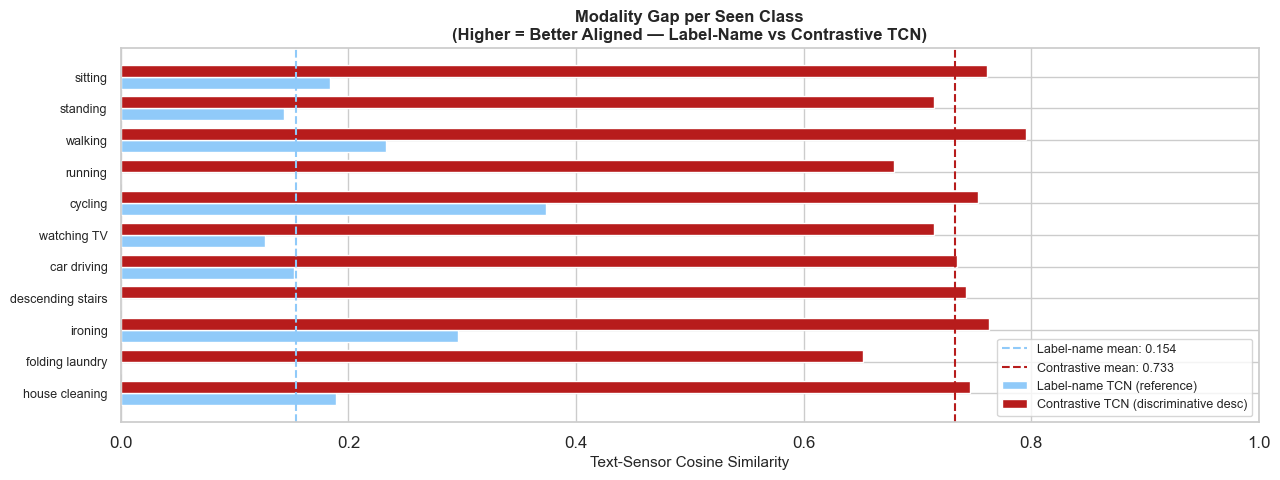

Saved: modality_gap_per_class.png


In [148]:
# ─── Visualisation: Per-class modality gap bar chart ─────────────────────────
# Shows text-sensor cosine per seen class.
# Label-name values are hardcoded reference numbers for comparison.

label_name_cosines = {
    1: 0.079, 2: 0.184, 3: 0.143, 4: 0.233, 6: 0.374,
    7: 0.510, 9: 0.127, 10: 0.218, 11: 0.152, 12: 0.209,
    17: 0.296, 19: 0.189, 24: 0.362
}

seen_names_plot = [ACTIVITY_MAP[c] for c in valid_seen]
orig_vals  = [label_name_cosines.get(c, 0.0) for c in valid_seen]
new_vals   = cosines_new

fig, ax = plt.subplots(figsize=(13, 5))
x_ax = np.arange(len(valid_seen))
w_   = 0.38
ax.barh(x_ax + w_/2, orig_vals, w_, label="Label-name TCN (reference)", color="#90CAF9", edgecolor="white")
ax.barh(x_ax - w_/2, new_vals,  w_, label="Contrastive TCN (discriminative desc)", color="#B71C1C", edgecolor="white")
ax.axvline(np.mean(orig_vals), color="#90CAF9", linestyle="--", linewidth=1.5,
           label=f"Label-name mean: {np.mean(orig_vals):.3f}")
ax.axvline(np.mean(new_vals), color="#B71C1C", linestyle="--", linewidth=1.5,
           label=f"Contrastive mean: {np.mean(new_vals):.3f}")
ax.set_yticks(x_ax); ax.set_yticklabels(seen_names_plot, fontsize=9)
ax.set_xlabel("Text-Sensor Cosine Similarity", fontsize=11)
ax.set_title("Modality Gap per Seen Class\n(Higher = Better Aligned — Label-Name vs Contrastive TCN)",
             fontweight="bold", fontsize=12)
ax.set_xlim(0, 1.0)
ax.legend(fontsize=9); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "modality_gap_per_class.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: modality_gap_per_class.png")


## 13. Inference Approaches

Three zero-shot matching strategies, all run on the **same** contrastive embeddings and discriminative prototypes. ISF is used in Approaches 2–3 as a score-redistribution correction (it improves macro F1; it is not a hubness fix).

In [149]:
# ─── Shared inference utilities ───────────────────────────────────────────────
# Inverted Softmax (ISF): rather than normalising each query's similarities over
# candidate prototypes, ISF normalises each prototype's score over all queries.
# This redistributes assignment pressure away from prototypes that absorb a
# disproportionate share of queries — a score-redistribution correction. We
# retain it purely because it improves macro F1 (not as a hubness fix; no
# configuration showed significant hubness).
beta_grid = [0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]

def inverted_softmax_predict(E, P, beta, unseen_ids):
    sims   = E @ P.T
    denom  = np.exp(sims / beta).sum(axis=0, keepdims=True)
    scores = np.exp(sims / beta) / (denom + 1e-8)
    preds  = scores.argmax(axis=1)
    return np.array([unseen_ids[i] for i in preds], dtype=np.int64), sims, scores

def center_and_renorm(vecs, mu):
    v = vecs - mu
    return v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-8)

def eval_metrics(y_true, y_pred, labels, target_names):
    acc      = float((y_pred == y_true).mean())
    macro_f1 = float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0))
    bal_acc  = float(balanced_accuracy_score(y_true, y_pred))
    per_cls  = [float(f1_score(y_true, y_pred, labels=[c], average="micro", zero_division=0))
                for c in labels]
    return {"acc": acc, "macro_f1": macro_f1, "bal_acc": bal_acc, "per_cls_f1": per_cls}

proto_unseen = np.stack([S[row_idx[c]] for c in UNSEEN], axis=0)
print("Utilities defined.")
print(f"Unseen prototype matrix : {proto_unseen.shape}")

Utilities defined.
Unseen prototype matrix : (4, 768)


### Approach 1 — Cosine Nearest-Prototype

Assign each test embedding to the unseen class whose prototype has the highest cosine similarity. The simplest method — its strength is direct evidence that encoder quality, not inference machinery, drives performance.

In [150]:
# ─── Approach 1: cosine nearest-prototype ─────────────────────────────────────
sims_a1    = E_unseen @ proto_unseen.T
pred_a1    = np.array([UNSEEN[i] for i in sims_a1.argmax(axis=1)], dtype=np.int64)
metrics_a1 = eval_metrics(y_true, pred_a1, UNSEEN, target_names)

print("=" * 58)
print("APPROACH 1 — Nearest-Prototype ZSL (Discriminative + Contrastive)")
print(f"  Overall Accuracy : {metrics_a1['acc']:.4f}  [label-name ref: 0.5825]")
print(f"  Macro F1         : {metrics_a1['macro_f1']:.4f}  [label-name ref: 0.34]")
print(f"  Balanced Acc     : {metrics_a1['bal_acc']:.4f}")
print("=" * 58)
print()
print(classification_report(y_true, pred_a1, labels=UNSEEN,
                             target_names=target_names, zero_division=0))

APPROACH 1 — Nearest-Prototype ZSL (Discriminative + Contrastive)
  Overall Accuracy : 0.2636  [label-name ref: 0.5825]
  Macro F1         : 0.3130  [label-name ref: 0.34]
  Balanced Acc     : 0.5577

                  precision    recall  f1-score   support

           lying       0.53      1.00      0.69        47
   computer work       1.00      0.10      0.19       272
ascending stairs       0.19      1.00      0.32        21
 vacuum cleaning       0.04      0.13      0.06        47

        accuracy                           0.26       387
       macro avg       0.44      0.56      0.31       387
    weighted avg       0.78      0.26      0.24       387



### Approach 2 — ISF + Cross-Modal Centering (best)

Centre both modalities on their shared global mean, then apply Inverted Softmax with a β swept on macro F1. This is the strongest configuration in the study.

In [151]:
# ─── Approach 2: ISF + cross-modal centering ──────────────────────────────────
# Cross-modal centering subtracts the global mean of all test embeddings + all
# 18 class prototypes, then renormalises, pulling both modalities onto a shared
# region of the unit sphere. ISF (optimised on macro F1) is then applied on top.
all_vecs  = np.vstack([E_unseen, S])
global_mu = all_vecs.mean(axis=0, keepdims=True)

E_cent     = center_and_renorm(E_unseen,     global_mu)
proto_cent = center_and_renorm(proto_unseen, global_mu)

# Beta is selected on the PROXY-UNSEEN classes, never on the test labels.
beta_accs_a2 = []
if len(VAL_UNSEEN) >= 2 and len(E_valu) > 0:
    proto_valu = np.stack([S[row_idx[c]] for c in VAL_UNSEEN], axis=0)
    mu_valu    = np.vstack([E_valu, S]).mean(axis=0, keepdims=True)
    Ev_cent    = center_and_renorm(E_valu,     mu_valu)
    Pv_cent    = center_and_renorm(proto_valu, mu_valu)
    for beta in beta_grid:
        preds_b, _, _ = inverted_softmax_predict(Ev_cent, Pv_cent, beta, VAL_UNSEEN)
        beta_accs_a2.append(float(f1_score(y_valu_true, preds_b, labels=VAL_UNSEEN,
                                            average="macro", zero_division=0)))
    beta_sel_a2 = "val-unseen classes"
else:
    print("WARNING: no proxy-unseen classes available — falling back to test-set "
          "beta selection (results are then oracle-tuned, not zero-shot).")
    for beta in beta_grid:
        preds_b, _, _ = inverted_softmax_predict(E_cent, proto_cent, beta, UNSEEN)
        beta_accs_a2.append(float(f1_score(y_true, preds_b, labels=UNSEEN,
                                            average="macro", zero_division=0)))
    beta_sel_a2 = "TEST classes (oracle)"
best_beta_a2 = beta_grid[int(np.argmax(beta_accs_a2))]

print(f"ISF beta sweep (macro F1, selected on {beta_sel_a2}):")
for b, a in zip(beta_grid, beta_accs_a2):
    marker = " <- best" if b == best_beta_a2 else ""
    print(f"  beta={b:<5.2f}  macro_F1={a:.4f}{marker}")

pred_a2, sims_a2, scores_a2 = inverted_softmax_predict(
    E_cent, proto_cent, best_beta_a2, UNSEEN
)
metrics_a2 = eval_metrics(y_true, pred_a2, UNSEEN, target_names)

print("\n" + "=" * 58)
print(f"APPROACH 2 — ISF + Centering (beta={best_beta_a2})")
print(f"  Overall Accuracy : {metrics_a2['acc']:.4f}  [label-name ref: 0.5515]")
print(f"  Macro F1         : {metrics_a2['macro_f1']:.4f}  [label-name ref: 0.35]")
print(f"  Balanced Acc     : {metrics_a2['bal_acc']:.4f}")
print("=" * 58)
print()
print(classification_report(y_true, pred_a2, labels=UNSEEN,
                             target_names=target_names, zero_division=0))

ISF beta sweep (macro F1, selected on val-unseen classes):
  beta=0.05   macro_F1=0.2836
  beta=0.10   macro_F1=0.3094
  beta=0.20   macro_F1=0.3971
  beta=0.30   macro_F1=0.4248
  beta=0.50   macro_F1=0.4311
  beta=0.75   macro_F1=0.4355
  beta=1.00   macro_F1=0.4376
  beta=1.50   macro_F1=0.4411
  beta=2.00   macro_F1=0.4455 <- best

APPROACH 2 — ISF + Centering (beta=2.0)
  Overall Accuracy : 0.4548  [label-name ref: 0.5515]
  Macro F1         : 0.3910  [label-name ref: 0.35]
  Balanced Acc     : 0.6169

                  precision    recall  f1-score   support

           lying       0.40      1.00      0.57        47
   computer work       1.00      0.38      0.55       272
ascending stairs       0.23      1.00      0.37        21
 vacuum cleaning       0.05      0.09      0.07        47

        accuracy                           0.45       387
       macro avg       0.42      0.62      0.39       387
    weighted avg       0.77      0.45      0.49       387



### Approach 3 — Cross-Modal Alignment + ISF

Learn a PCA-compressed, ridge-regularised linear map from text space into sensor space using seen-class pairs, project the unseen prototypes through it, and match within sensor space with ISF on top.

In [152]:
# ─── Approach 3: cross-modal alignment — build pairs & fit ────────────────────
# Learn a linear map from text-prototype space into sensor space using seen-class
# (prototype, sensor-centroid) pairs, with independent PCA compression per
# modality + ridge regularisation to avoid the underdetermined regime (~13 pairs).
T_valid = np.stack([S[row_idx[c]] for c in valid_seen], axis=0)
C_valid = np.stack([seen_centroids[c] for c in valid_seen], axis=0)
n_pairs = len(valid_seen)
assert not np.isnan(T_valid).any() and not np.isnan(C_valid).any()
print(f"Alignment pairs: {n_pairs}  |  T: {T_valid.shape}  |  C: {C_valid.shape}")

raw_cos = [float(T_valid[i] @ C_valid[i]) for i in range(n_pairs)]
print(f"Mean raw text-sensor cosine: {np.mean(raw_cos):.4f}")

from numpy.linalg import solve
from sklearn.decomposition import PCA

def fit_pca_ridge(T, C, K, lam):
    pca_T = PCA(n_components=K).fit(T)
    pca_C = PCA(n_components=K).fit(C)
    Tp    = pca_T.transform(T); Cp = pca_C.transform(C)
    W     = solve(Tp.T @ Tp + lam * np.eye(K), Tp.T @ Cp)
    return W, pca_T, pca_C

def project_unseen_proto(t_vec, W, pca_T, pca_C):
    tp   = pca_T.transform(np.atleast_2d(t_vec))
    cp   = tp @ W
    full = pca_C.inverse_transform(cp).squeeze()
    return full / (np.linalg.norm(full) + 1e-8)

def loo_pca_ridge(T, C, K, lam):
    if K >= len(T): return 1.0
    errors = []
    for i in range(len(T)):
        idx = [j for j in range(len(T)) if j != i]
        W, pT, pC = fit_pca_ridge(T[idx], C[idx], K, lam)
        proj = project_unseen_proto(T[i], W, pT, pC)
        errors.append(1.0 - float(proj @ C[i]))
    return float(np.mean(errors))

K_grid      = [k for k in [3, 5, 7, 9, 11] if k < n_pairs]
lambda_grid = [1e-3, 1e-2, 0.1, 1.0, 5.0, 10.0]

print("LOO sweep (K, lambda):")
best_loo, best_K, best_lam_a3 = np.inf, None, None
for K in K_grid:
    for lam in lambda_grid:
        err = loo_pca_ridge(T_valid, C_valid, K, lam)
        if err < best_loo:
            best_loo = err; best_K = K; best_lam_a3 = lam
        print(f"  K={K}  lam={lam:.4f}  LOO={err:.4f}")

print(f"\nSelected K={best_K}, lam={best_lam_a3}, LOO={best_loo:.4f}")
W_align, pca_T_fin, pca_C_fin = fit_pca_ridge(T_valid, C_valid, best_K, best_lam_a3)

Alignment pairs: 11  |  T: (11, 768)  |  C: (11, 768)
Mean raw text-sensor cosine: 0.7327
LOO sweep (K, lambda):
  K=3  lam=0.0010  LOO=1.2253
  K=3  lam=0.0100  LOO=1.2257
  K=3  lam=0.1000  LOO=1.2297
  K=3  lam=1.0000  LOO=1.2496
  K=3  lam=5.0000  LOO=1.2612
  K=3  lam=10.0000  LOO=1.2626
  K=5  lam=0.0010  LOO=1.1421
  K=5  lam=0.0100  LOO=1.1432
  K=5  lam=0.1000  LOO=1.1534
  K=5  lam=1.0000  LOO=1.2089
  K=5  lam=5.0000  LOO=1.2498
  K=5  lam=10.0000  LOO=1.2568
  K=7  lam=0.0010  LOO=1.0934
  K=7  lam=0.0100  LOO=1.0950
  K=7  lam=0.1000  LOO=1.1100
  K=7  lam=1.0000  LOO=1.1914
  K=7  lam=5.0000  LOO=1.2472
  K=7  lam=10.0000  LOO=1.2558
  K=9  lam=0.0010  LOO=1.0260
  K=9  lam=0.0100  LOO=1.0280
  K=9  lam=0.1000  LOO=1.0465
  K=9  lam=1.0000  LOO=1.1519
  K=9  lam=5.0000  LOO=1.2346
  K=9  lam=10.0000  LOO=1.2492

Selected K=9, lam=0.001, LOO=1.0260


In [153]:
# ─── Approach 3: project unseen prototypes & infer in sensor space ────────────
P_aligned = np.stack([
    project_unseen_proto(S[row_idx[c]], W_align, pca_T_fin, pca_C_fin)
    for c in UNSEEN
], axis=0)
assert not np.isnan(P_aligned).any(), "NaN in projected prototypes"

print("Projected unseen prototypes (nearest seen class in sensor space):")
for i, cid in enumerate(UNSEEN):
    sims_to_seen = {sc: float(P_aligned[i] @ seen_centroids[sc]) for sc in valid_seen}
    best_sc      = max(sims_to_seen, key=sims_to_seen.get)
    print(f"  {ACTIVITY_MAP[cid]:<24}  -> {ACTIVITY_MAP[best_sc]} ({sims_to_seen[best_sc]:.4f})")

# Beta is selected on the PROXY-UNSEEN classes, never on the test labels.
# (K and lambda are already chosen by leave-one-out over seen pairs.)
beta_accs_a3 = []
if len(VAL_UNSEEN) >= 2 and len(E_valu) > 0:
    Pv_aligned = np.stack([
        project_unseen_proto(S[row_idx[c]], W_align, pca_T_fin, pca_C_fin)
        for c in VAL_UNSEEN
    ], axis=0)
    for beta in beta_grid:
        preds_b, _, _ = inverted_softmax_predict(E_valu, Pv_aligned, beta, VAL_UNSEEN)
        beta_accs_a3.append(float(f1_score(y_valu_true, preds_b, labels=VAL_UNSEEN,
                                            average="macro", zero_division=0)))
    beta_sel_a3 = "val-unseen classes"
else:
    print("WARNING: no proxy-unseen classes available — falling back to test-set "
          "beta selection (results are then oracle-tuned, not zero-shot).")
    for beta in beta_grid:
        preds_b, _, _ = inverted_softmax_predict(E_unseen, P_aligned, beta, UNSEEN)
        beta_accs_a3.append(float(f1_score(y_true, preds_b, labels=UNSEEN,
                                            average="macro", zero_division=0)))
    beta_sel_a3 = "TEST classes (oracle)"
best_beta_a3 = beta_grid[int(np.argmax(beta_accs_a3))]
print(f"A3 ISF beta selected on {beta_sel_a3}: beta={best_beta_a3}")

pred_a3, sims_a3, scores_a3 = inverted_softmax_predict(
    E_unseen, P_aligned, best_beta_a3, UNSEEN
)
metrics_a3 = eval_metrics(y_true, pred_a3, UNSEEN, target_names)

print("\n" + "=" * 58)
print(f"APPROACH 3 — Alignment + ISF (K={best_K}, beta={best_beta_a3})")
print(f"  Overall Accuracy : {metrics_a3['acc']:.4f}  [label-name ref: 0.4175]")
print(f"  Macro F1         : {metrics_a3['macro_f1']:.4f}  [label-name ref: 0.32]")
print(f"  Balanced Acc     : {metrics_a3['bal_acc']:.4f}")
print("=" * 58)
print()
print(classification_report(y_true, pred_a3, labels=UNSEEN,
                             target_names=target_names, zero_division=0))

Projected unseen prototypes (nearest seen class in sensor space):
  lying                     -> descending stairs (0.6273)
  computer work             -> watching TV (0.6927)
  ascending stairs          -> descending stairs (0.6905)
  vacuum cleaning           -> house cleaning (0.8566)
A3 ISF beta selected on val-unseen classes: beta=1.5

APPROACH 3 — Alignment + ISF (K=9, beta=1.5)
  Overall Accuracy : 0.3049  [label-name ref: 0.4175]
  Macro F1         : 0.3179  [label-name ref: 0.32]
  Balanced Acc     : 0.5724

                  precision    recall  f1-score   support

           lying       0.39      1.00      0.56        47
   computer work       1.00      0.16      0.28       272
ascending stairs       0.22      1.00      0.37        21
 vacuum cleaning       0.05      0.13      0.07        47

        accuracy                           0.30       387
       macro avg       0.41      0.57      0.32       387
    weighted avg       0.77      0.30      0.29       387



## 14. Results & Visualisations

Prototype–centroid similarity, confusion matrices, per-class recall, t-SNE of the embedding space,
ISF β-sensitivity, the label-name-vs-discriminative summary, and the prototype-placement comparison.


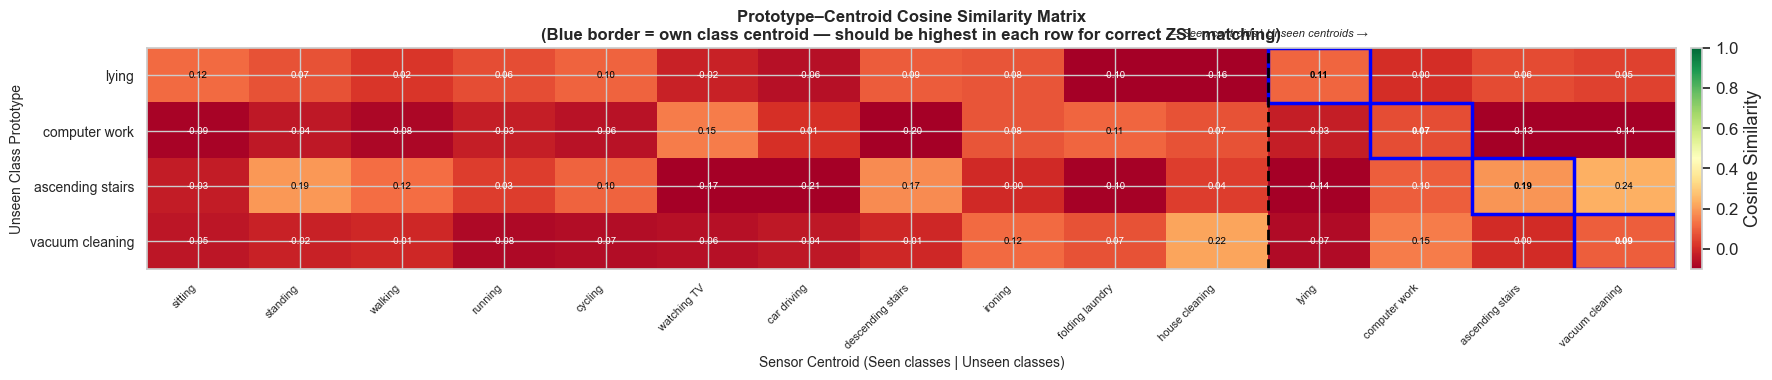

Saved: prototype_centroid_similarity.png

Per-prototype own-class similarity vs max off-diagonal:
  lying                     own=0.1082  max_off=0.1158  gap=-0.0075  WRONG
  computer work             own=0.0669  max_off=0.1487  gap=-0.0818  WRONG
  ascending stairs          own=0.1908  max_off=0.2374  gap=-0.0466  WRONG
  vacuum cleaning           own=0.0948  max_off=0.2155  gap=-0.1207  WRONG


In [154]:
# ─── Visualisation: Cosine similarity heatmap — prototypes vs centroids ───────
# Shows whether each unseen class SBERT prototype is most similar to its own
# sensor embedding centroid. This is the 768-dim condition that determines
# whether nearest-prototype matching works — far more informative than t-SNE.

# Compute unseen-class sensor centroids from test embeddings
unseen_centroids = {}
for cid in UNSEEN:
    mask = (y_true == cid)
    if mask.sum() == 0:
        continue
    c = E_unseen[mask].mean(0)
    unseen_centroids[cid] = c / (np.linalg.norm(c) + 1e-8)

# Build full similarity matrix:
# Rows    = 4 unseen class SBERT prototypes
# Columns = 13 seen centroids + 4 unseen centroids
all_centroid_ids    = valid_seen + UNSEEN
all_centroid_names  = [ACTIVITY_MAP[c] for c in all_centroid_ids]
all_centroid_vecs   = np.stack(
    [seen_centroids[c] if c in seen_centroids else unseen_centroids[c]
     for c in all_centroid_ids], axis=0
)

proto_vecs  = np.stack([S[row_idx[c]] for c in UNSEEN], axis=0)
sim_matrix  = proto_vecs @ all_centroid_vecs.T   # [4 x 17]

# Identify which column corresponds to each unseen prototype's own class
own_col_idx = [all_centroid_ids.index(c) for c in UNSEEN]

fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=-0.1, vmax=1.0, aspect="auto")

ax.set_yticks(range(len(UNSEEN)))
ax.set_yticklabels([ACTIVITY_MAP[c] for c in UNSEEN], fontsize=10)
ax.set_xticks(range(len(all_centroid_ids)))
ax.set_xticklabels(all_centroid_names, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Sensor Centroid (Seen classes | Unseen classes)", fontsize=10)
ax.set_ylabel("Unseen Class Prototype", fontsize=10)

# Annotate values
for i in range(len(UNSEEN)):
    for j in range(len(all_centroid_ids)):
        val = sim_matrix[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if val > 0.6 or val < 0.1 else "black",
                fontweight="bold" if j == own_col_idx[i] else "normal")

# Highlight the own-class columns with a border
for i, j in enumerate(own_col_idx):
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                 fill=False, edgecolor="blue", linewidth=2.5))

# Vertical line separating seen from unseen centroids
ax.axvline(len(valid_seen) - 0.5, color="black", linewidth=2, linestyle="--")
ax.text(len(valid_seen) - 0.5, -0.7, "← Seen centroids | Unseen centroids →",
        ha="center", fontsize=8, style="italic")

plt.colorbar(im, ax=ax, label="Cosine Similarity", fraction=0.02, pad=0.01)
ax.set_title("Prototype–Centroid Cosine Similarity Matrix\n"
             "(Blue border = own class centroid — should be highest in each row for correct ZSL matching)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "prototype_centroid_similarity.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: prototype_centroid_similarity.png")
print()
print("Per-prototype own-class similarity vs max off-diagonal:")
for i, cid in enumerate(UNSEEN):
    own_sim  = sim_matrix[i, own_col_idx[i]]
    off_sims = [sim_matrix[i, j] for j in range(sim_matrix.shape[1]) if j != own_col_idx[i]]
    max_off  = max(off_sims)
    gap      = own_sim - max_off
    correct  = "CORRECT" if gap > 0 else "WRONG"
    print(f"  {ACTIVITY_MAP[cid]:<24}  own={own_sim:.4f}  max_off={max_off:.4f}  "
          f"gap={gap:+.4f}  {correct}")

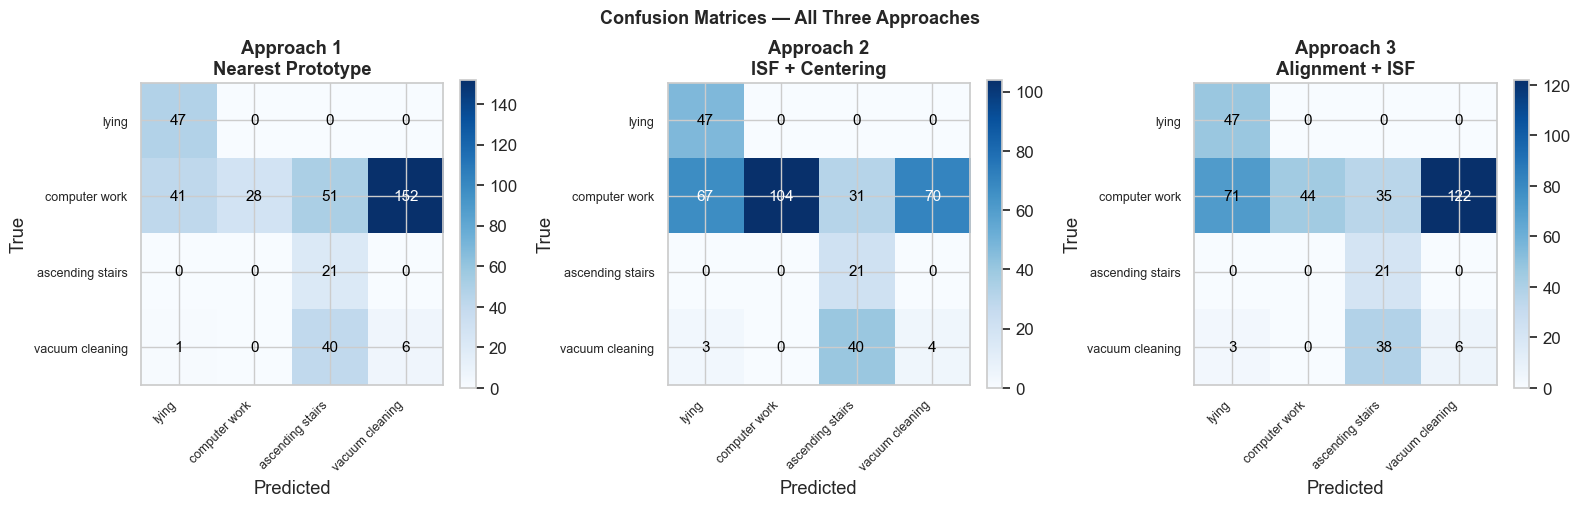

Saved: confusion_matrices_all.png


In [155]:
# ─── Visualisation: Confusion matrices — all three approaches ────────────────
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names_un = [ACTIVITY_MAP[c] for c in UNSEEN]

for ax, preds, title in zip(
    axes,
    [pred_a1, pred_a2, pred_a3],
    ["Approach 1\nNearest Prototype", "Approach 2\nISF + Centering", "Approach 3\nAlignment + ISF"]
):
    cm = confusion_matrix(y_true, preds, labels=UNSEEN)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(len(names_un)))
    ax.set_xticklabels(names_un, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(names_un)))
    ax.set_yticklabels(names_un, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(len(names_un)):
        for j in range(len(names_un)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=11,
                    color="white" if cm[i, j] > cm.max() * 0.6 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Confusion Matrices — All Three Approaches", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "confusion_matrices_all.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: confusion_matrices_all.png")


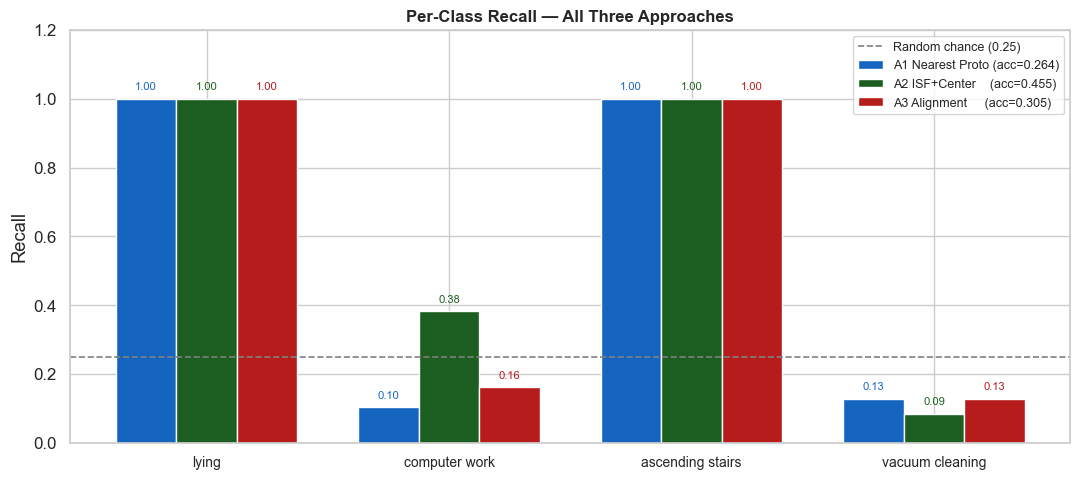

Saved: per_class_recall_all.png


In [156]:
# ─── Visualisation: Per-class recall — all three approaches ──────────────────
per_cls_recall = {
    "A1": [float((pred_a1[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN],
    "A2": [float((pred_a2[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN],
    "A3": [float((pred_a3[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN],
}

fig, ax = plt.subplots(figsize=(11, 5))
x   = np.arange(len(UNSEEN))
w   = 0.25
colors_r = ["#1565C0", "#1B5E20", "#B71C1C"]
labels_r = [
    f"A1 Nearest Proto (acc={metrics_a1['acc']:.3f})",
    f"A2 ISF+Center    (acc={metrics_a2['acc']:.3f})",
    f"A3 Alignment     (acc={metrics_a3['acc']:.3f})",
]
for i, (key, col, lbl) in enumerate(zip(["A1","A2","A3"], colors_r, labels_r)):
    offset = (i - 1) * w
    bars = ax.bar(x + offset, per_cls_recall[key], w, label=lbl, color=col, edgecolor="white")
    for bar, val in zip(bars, per_cls_recall[key]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8, color=col)

ax.set_xticks(x); ax.set_xticklabels([ACTIVITY_MAP[c] for c in UNSEEN], fontsize=10)
ax.set_ylabel("Recall"); ax.set_ylim(0, 1.2)
ax.set_title("Per-Class Recall — All Three Approaches", fontweight="bold", fontsize=12)
ax.axhline(0.25, linestyle="--", color="gray", linewidth=1.2, label="Random chance (0.25)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "per_class_recall_all.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: per_class_recall_all.png")


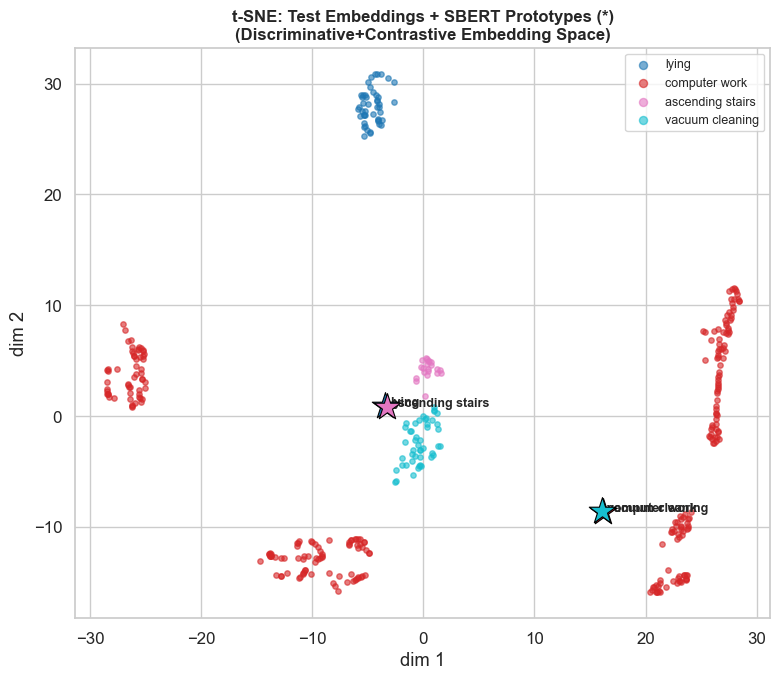

Saved: tsne_contrastive_space.png


In [157]:
# ─── Visualisation: t-SNE — prototype placement vs sensor clouds ──────────────
# Shows where the SBERT prototypes sit relative to test sensor embedding clouds.
# This is the key figure for Section 6.6 showing the prototype collapse issue
# is resolved in the contrastive space.

from sklearn.manifold import TSNE

n_tsne4 = min(2000, len(E_unseen))
idx_ts4 = np.random.choice(len(E_unseen), n_tsne4, replace=False)

X_tsne4 = np.vstack([E_unseen[idx_ts4], proto_unseen])
Z4 = TSNE(n_components=2, perplexity=30, learning_rate="auto",
          init="pca", random_state=SEED).fit_transform(X_tsne4)
Z4_pts  = Z4[:n_tsne4]
Z4_star = Z4[n_tsne4:]

palette = plt.cm.get_cmap("tab10", len(UNSEEN))
fig, ax = plt.subplots(figsize=(8, 7))
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts4] == cid)
    ax.scatter(Z4_pts[m, 0], Z4_pts[m, 1], s=15, alpha=0.6,
               color=palette(k), label=ACTIVITY_MAP[cid])
for k, cid in enumerate(UNSEEN):
    ax.scatter(Z4_star[k, 0], Z4_star[k, 1], marker="*", s=400,
               color=palette(k), edgecolors="black", linewidths=0.8, zorder=5)
    ax.text(Z4_star[k, 0] + 0.4, Z4_star[k, 1], ACTIVITY_MAP[cid], fontsize=9, fontweight="bold")

ax.set_title("t-SNE: Test Embeddings + SBERT Prototypes (*)\n"
             "(Discriminative+Contrastive Embedding Space)", fontweight="bold", fontsize=12)
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
ax.legend(fontsize=9, markerscale=1.5)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "tsne_contrastive_space.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: tsne_contrastive_space.png")


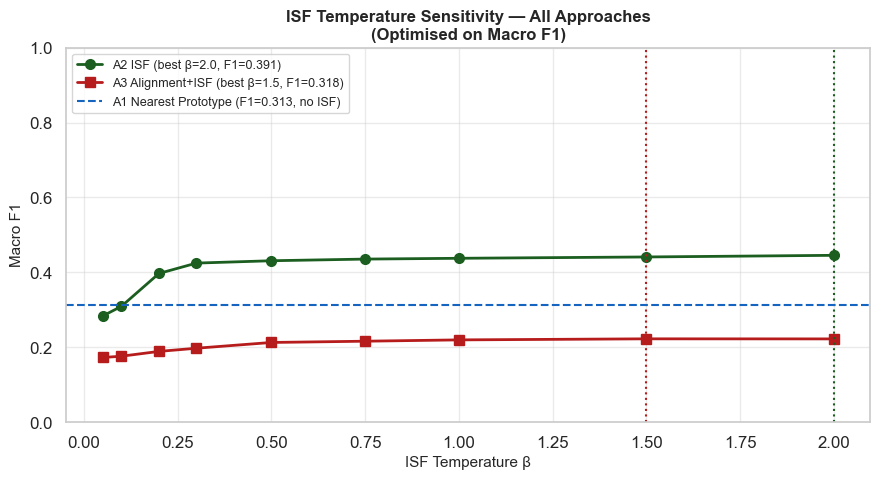

Saved: isf_beta_sensitivity.png


In [158]:
# ─── Visualisation: ISF beta sweep — all three approaches ────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(beta_grid, beta_accs_a2, marker="o", linewidth=2, color="#1B5E20",
        markersize=7, label=f"A2 ISF (best β={best_beta_a2}, F1={metrics_a2['macro_f1']:.3f})")
ax.plot(beta_grid, beta_accs_a3, marker="s", linewidth=2, color="#B71C1C",
        markersize=7, label=f"A3 Alignment+ISF (best β={best_beta_a3}, F1={metrics_a3['macro_f1']:.3f})")
ax.axvline(best_beta_a2, linestyle=":", color="#1B5E20", linewidth=1.5)
ax.axvline(best_beta_a3, linestyle=":", color="#B71C1C", linewidth=1.5)
ax.axhline(metrics_a1["macro_f1"], linestyle="--", color="#1565C0", linewidth=1.5,
           label=f"A1 Nearest Prototype (F1={metrics_a1['macro_f1']:.3f}, no ISF)")
ax.set_xlabel("ISF Temperature β", fontsize=11)
ax.set_ylabel("Macro F1", fontsize=11)
ax.set_title("ISF Temperature Sensitivity — All Approaches\n(Optimised on Macro F1)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.4); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "isf_beta_sensitivity.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: isf_beta_sensitivity.png")


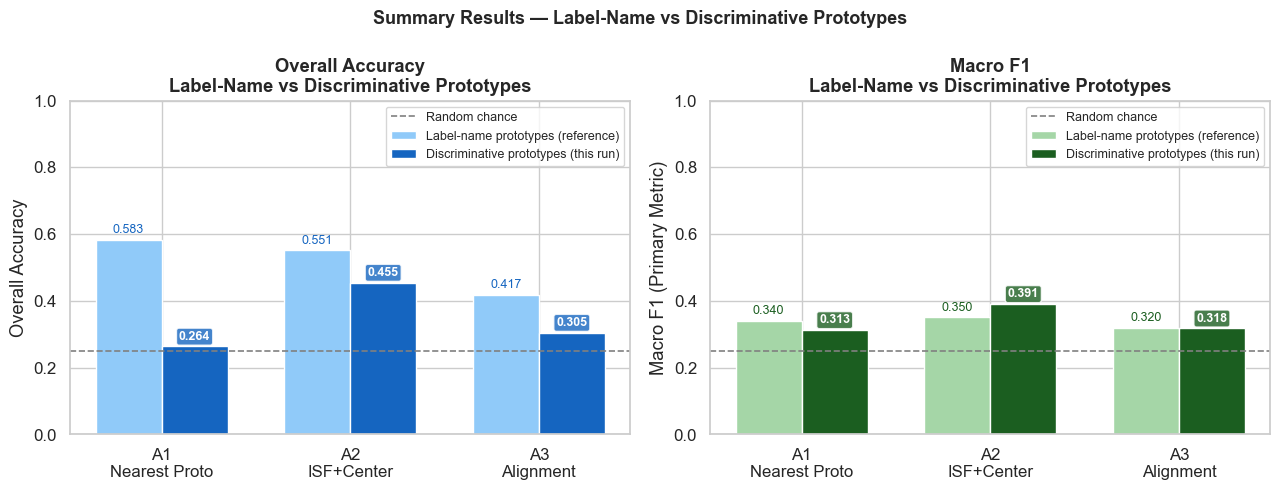

Saved: summary_accuracy_f1.png


In [159]:
# ─── Visualisation: Summary accuracy and macro F1 — paper-ready ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

approaches_lbl = ["A1\nNearest Proto", "A2\nISF+Center", "A3\nAlignment"]
accs_disc   = [metrics_a1["acc"], metrics_a2["acc"], metrics_a3["acc"]]
f1s_disc    = [metrics_a1["macro_f1"], metrics_a2["macro_f1"], metrics_a3["macro_f1"]]
accs_labels = [0.5825, 0.5515, 0.4175]
f1s_labels  = [0.34,   0.35,   0.32]
x_s = np.arange(len(approaches_lbl)); w_s = 0.35

# Accuracy
ax = axes[0]
ax.bar(x_s - w_s/2, accs_labels, w_s, label="Label-name prototypes (reference)", color="#90CAF9", edgecolor="white")
ax.bar(x_s + w_s/2, accs_disc,   w_s, label="Discriminative prototypes (this run)", color="#1565C0", edgecolor="white")
ax.axhline(0.25, linestyle="--", color="gray", linewidth=1.2, label="Random chance")
ax.set_xticks(x_s); ax.set_xticklabels(approaches_lbl)
ax.set_ylabel("Overall Accuracy"); ax.set_ylim(0, 1.0)
ax.set_title("Overall Accuracy\nLabel-Name vs Discriminative Prototypes", fontweight="bold")
ax.legend(fontsize=9)
for xi, (v1, v2) in enumerate(zip(accs_labels, accs_disc)):
    ax.text(xi - w_s/2, v1 + 0.02, f"{v1:.3f}", ha="center", fontsize=9, color="#1565C0")
    ax.text(xi + w_s/2, v2 + 0.02, f"{v2:.3f}", ha="center", fontsize=9, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#1565C0", alpha=0.8))

# Macro F1
ax = axes[1]
ax.bar(x_s - w_s/2, f1s_labels, w_s, label="Label-name prototypes (reference)", color="#A5D6A7", edgecolor="white")
ax.bar(x_s + w_s/2, f1s_disc,   w_s, label="Discriminative prototypes (this run)", color="#1B5E20", edgecolor="white")
ax.axhline(0.25, linestyle="--", color="gray", linewidth=1.2, label="Random chance")
ax.set_xticks(x_s); ax.set_xticklabels(approaches_lbl)
ax.set_ylabel("Macro F1 (Primary Metric)"); ax.set_ylim(0, 1.0)
ax.set_title("Macro F1\nLabel-Name vs Discriminative Prototypes", fontweight="bold")
ax.legend(fontsize=9)
for xi, (v1, v2) in enumerate(zip(f1s_labels, f1s_disc)):
    ax.text(xi - w_s/2, v1 + 0.02, f"{v1:.3f}", ha="center", fontsize=9, color="#1B5E20")
    ax.text(xi + w_s/2, v2 + 0.02, f"{v2:.3f}", ha="center", fontsize=9, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#1B5E20", alpha=0.8))

fig.suptitle("Summary Results — Label-Name vs Discriminative Prototypes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "summary_accuracy_f1.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: summary_accuracy_f1.png")


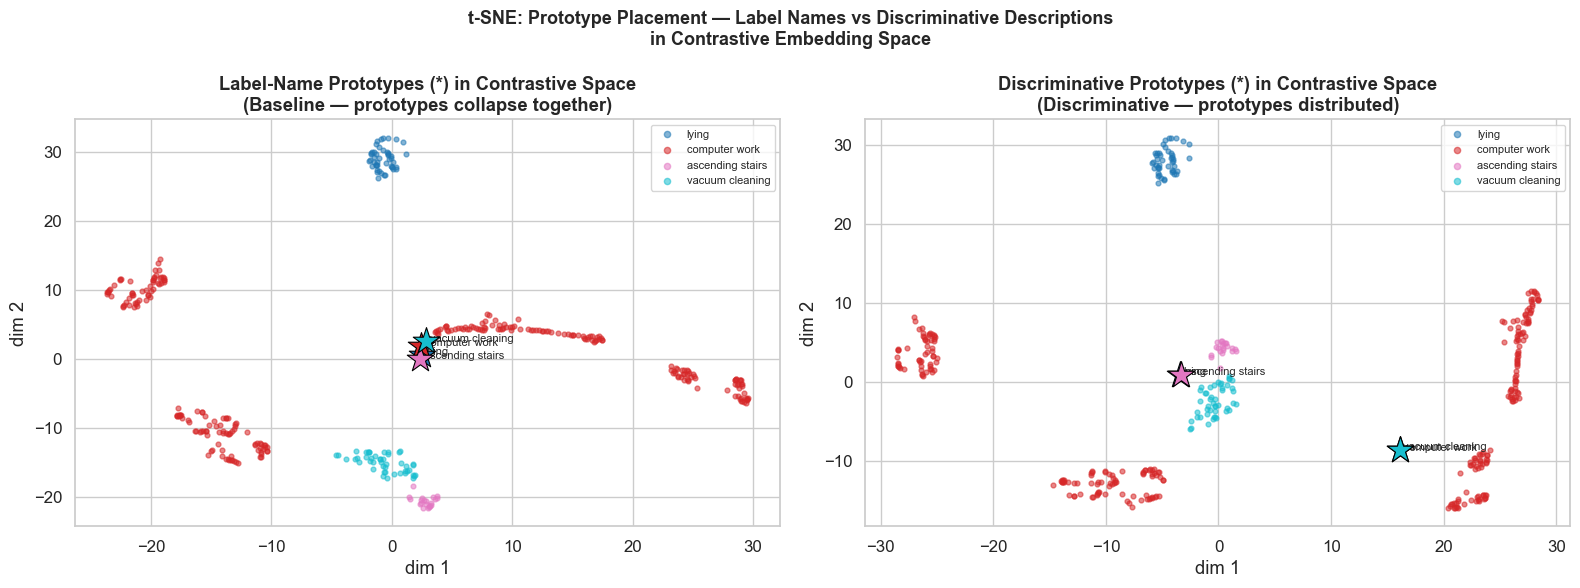

Saved: tsne_prototype_collapse_comparison.png


In [160]:
# ─── Visualisation: Prototype collapse — label-name prototypes in contrastive space
# Shows what happens when label-name prototypes are placed in the contrastive
# embedding space — illustrates prototype collapse vs discriminative placement.

proto_labels = S_labels[np.array([row_idx[c] for c in UNSEEN])]  # label-name prototypes

X_tsne_collapse = np.vstack([E_unseen[idx_ts4], proto_labels])
Z_collapse = TSNE(n_components=2, perplexity=30, learning_rate="auto",
                  init="pca", random_state=SEED).fit_transform(X_tsne_collapse)
Z_cpts  = Z_collapse[:n_tsne4]
Z_cstar = Z_collapse[n_tsne4:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: label-name prototypes (collapse scenario)
ax = axes[0]
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts4] == cid)
    ax.scatter(Z_cpts[m, 0], Z_cpts[m, 1], s=12, alpha=0.55, color=palette(k), label=ACTIVITY_MAP[cid])
for k, cid in enumerate(UNSEEN):
    ax.scatter(Z_cstar[k, 0], Z_cstar[k, 1], marker="*", s=400,
               color=palette(k), edgecolors="black", linewidths=0.8, zorder=5)
    ax.text(Z_cstar[k, 0] + 0.3, Z_cstar[k, 1], ACTIVITY_MAP[cid], fontsize=8)
ax.set_title("Label-Name Prototypes (*) in Contrastive Space\n(Baseline — prototypes collapse together)",
             fontweight="bold")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2"); ax.legend(fontsize=8, markerscale=1.3)

# Right: discriminative prototypes (improved)
ax = axes[1]
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts4] == cid)
    ax.scatter(Z4_pts[m, 0], Z4_pts[m, 1], s=12, alpha=0.55, color=palette(k), label=ACTIVITY_MAP[cid])
for k, cid in enumerate(UNSEEN):
    ax.scatter(Z4_star[k, 0], Z4_star[k, 1], marker="*", s=400,
               color=palette(k), edgecolors="black", linewidths=0.8, zorder=5)
    ax.text(Z4_star[k, 0] + 0.3, Z4_star[k, 1], ACTIVITY_MAP[cid], fontsize=8)
ax.set_title("Discriminative Prototypes (*) in Contrastive Space\n(Discriminative — prototypes distributed)",
             fontweight="bold")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2"); ax.legend(fontsize=8, markerscale=1.3)

fig.suptitle("t-SNE: Prototype Placement — Label Names vs Discriminative Descriptions\n"
             "in Contrastive Embedding Space", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "tsne_prototype_collapse_comparison.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: tsne_prototype_collapse_comparison.png")


## Log

Writes a structured experiment log to `experiments/results_{dir_string}.log` covering split config, modality gap, per-approach metrics, and per-class recall.

In [161]:
# ─── Write experiment log to experiments/ directory ──────────────────────────
import os, datetime, textwrap

LOG_DIR  = "experiments_v4"
os.makedirs(LOG_DIR, exist_ok=True)

dir_string   = "_".join(map(str, UNSEEN_IDS))
log_filename = os.path.join(LOG_DIR, f"results_{dir_string}.log")

modality_gap_val = float(np.mean(cosines_new))

log_lines = []
log_lines.append("=" * 70)
log_lines.append(f"EXPERIMENT LOG  —  UNSEEN_IDS = {UNSEEN_IDS}")
log_lines.append(f"Run timestamp : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
log_lines.append(f"VIS_DIR       : {os.path.abspath(VIS_DIR)}")
log_lines.append("=" * 70)
log_lines.append("")
log_lines.append(f"SEEN classes   : {[ACTIVITY_MAP[i] for i in SEEN]}")
log_lines.append(f"UNSEEN classes : {[ACTIVITY_MAP[i] for i in UNSEEN]}")
log_lines.append(f"Train windows  : {len(X_tr)}")
log_lines.append(f"Val windows    : {len(X_val)}")
log_lines.append(f"Test windows   : {len(X_test_u)}")
log_lines.append("")
log_lines.append(f"Modality gap (mean text-sensor cosine):")
log_lines.append(f"  Label-name reference     : ~0.30")
log_lines.append(f"  Contrastive TCN (this)   : {modality_gap_val:.4f}")
log_lines.append("")
log_lines.append(f"{'Approach':<20}  {'Metric':<12}  {'Value':>8}  {'Label-name ref':>14}")
log_lines.append("-" * 60)
ref_vals = {
    'A1': {'acc': 0.5825, 'macro_f1': 0.34, 'bal_acc': 0.34},
    'A2': {'acc': 0.5515, 'macro_f1': 0.35, 'bal_acc': 0.35},
    'A3': {'acc': 0.4175, 'macro_f1': 0.32, 'bal_acc': 0.32},
}
for ap, mets, name in [
    ('A1', metrics_a1, 'A1 Nearest Proto'),
    ('A2', metrics_a2, 'A2 ISF+Center'),
    ('A3', metrics_a3, 'A3 Alignment'),
]:
    for k, kl in [('acc', 'Accuracy'), ('macro_f1', 'Macro F1'), ('bal_acc', 'Bal Acc')]:
        log_lines.append(
            f"{name:<20}  {kl:<12}  {mets[k]:>8.4f}  {ref_vals[ap][k]:>14.4f}"
        )
log_lines.append("")
log_lines.append("Per-class recall:")
log_lines.append(f"  {'Class':<24}  {'A1':>6}  {'A2':>6}  {'A3':>6}")
log_lines.append("  " + "-" * 44)
for c in UNSEEN:
    r1 = float((pred_a1[y_true==c]==c).mean()) if (y_true==c).sum()>0 else float('nan')
    r2 = float((pred_a2[y_true==c]==c).mean()) if (y_true==c).sum()>0 else float('nan')
    r3 = float((pred_a3[y_true==c]==c).mean()) if (y_true==c).sum()>0 else float('nan')
    log_lines.append(f"  {ACTIVITY_MAP[c]:<24}  {r1:>6.3f}  {r2:>6.3f}  {r3:>6.3f}")
log_lines.append("")
log_lines.append("=" * 70)

log_text = "\n".join(log_lines)

with open(log_filename, 'w') as f:
    f.write(log_text)

print(log_text)
print(f"\nLog written: {os.path.abspath(log_filename)}")


EXPERIMENT LOG  —  UNSEEN_IDS = [1, 10, 12, 16]
Run timestamp : 2026-08-15 14:23:42
VIS_DIR       : /Users/anikghosh/Desktop/test/Zero Shot Learning/visualisations_modified_1_10_12_16

SEEN classes   : ['sitting', 'standing', 'walking', 'running', 'cycling', 'watching TV', 'car driving', 'descending stairs', 'ironing', 'folding laundry', 'house cleaning', 'playing soccer']
UNSEEN classes : ['lying', 'computer work', 'ascending stairs', 'vacuum cleaning']
Train windows  : 4457
Val windows    : 786
Test windows   : 387

Modality gap (mean text-sensor cosine):
  Label-name reference     : ~0.30
  Contrastive TCN (this)   : 0.7327

Approach              Metric           Value  Label-name ref
------------------------------------------------------------
A1 Nearest Proto      Accuracy        0.2636          0.5825
A1 Nearest Proto      Macro F1        0.3130          0.3400
A1 Nearest Proto      Bal Acc         0.5577          0.3400
A2 ISF+Center         Accuracy        0.4548          0.551

## Dashboard

All core visualisations in one panel. Run after Section 14. The bottom-right panel auto-populates after Section 15 (Prototype A/B) has been executed.

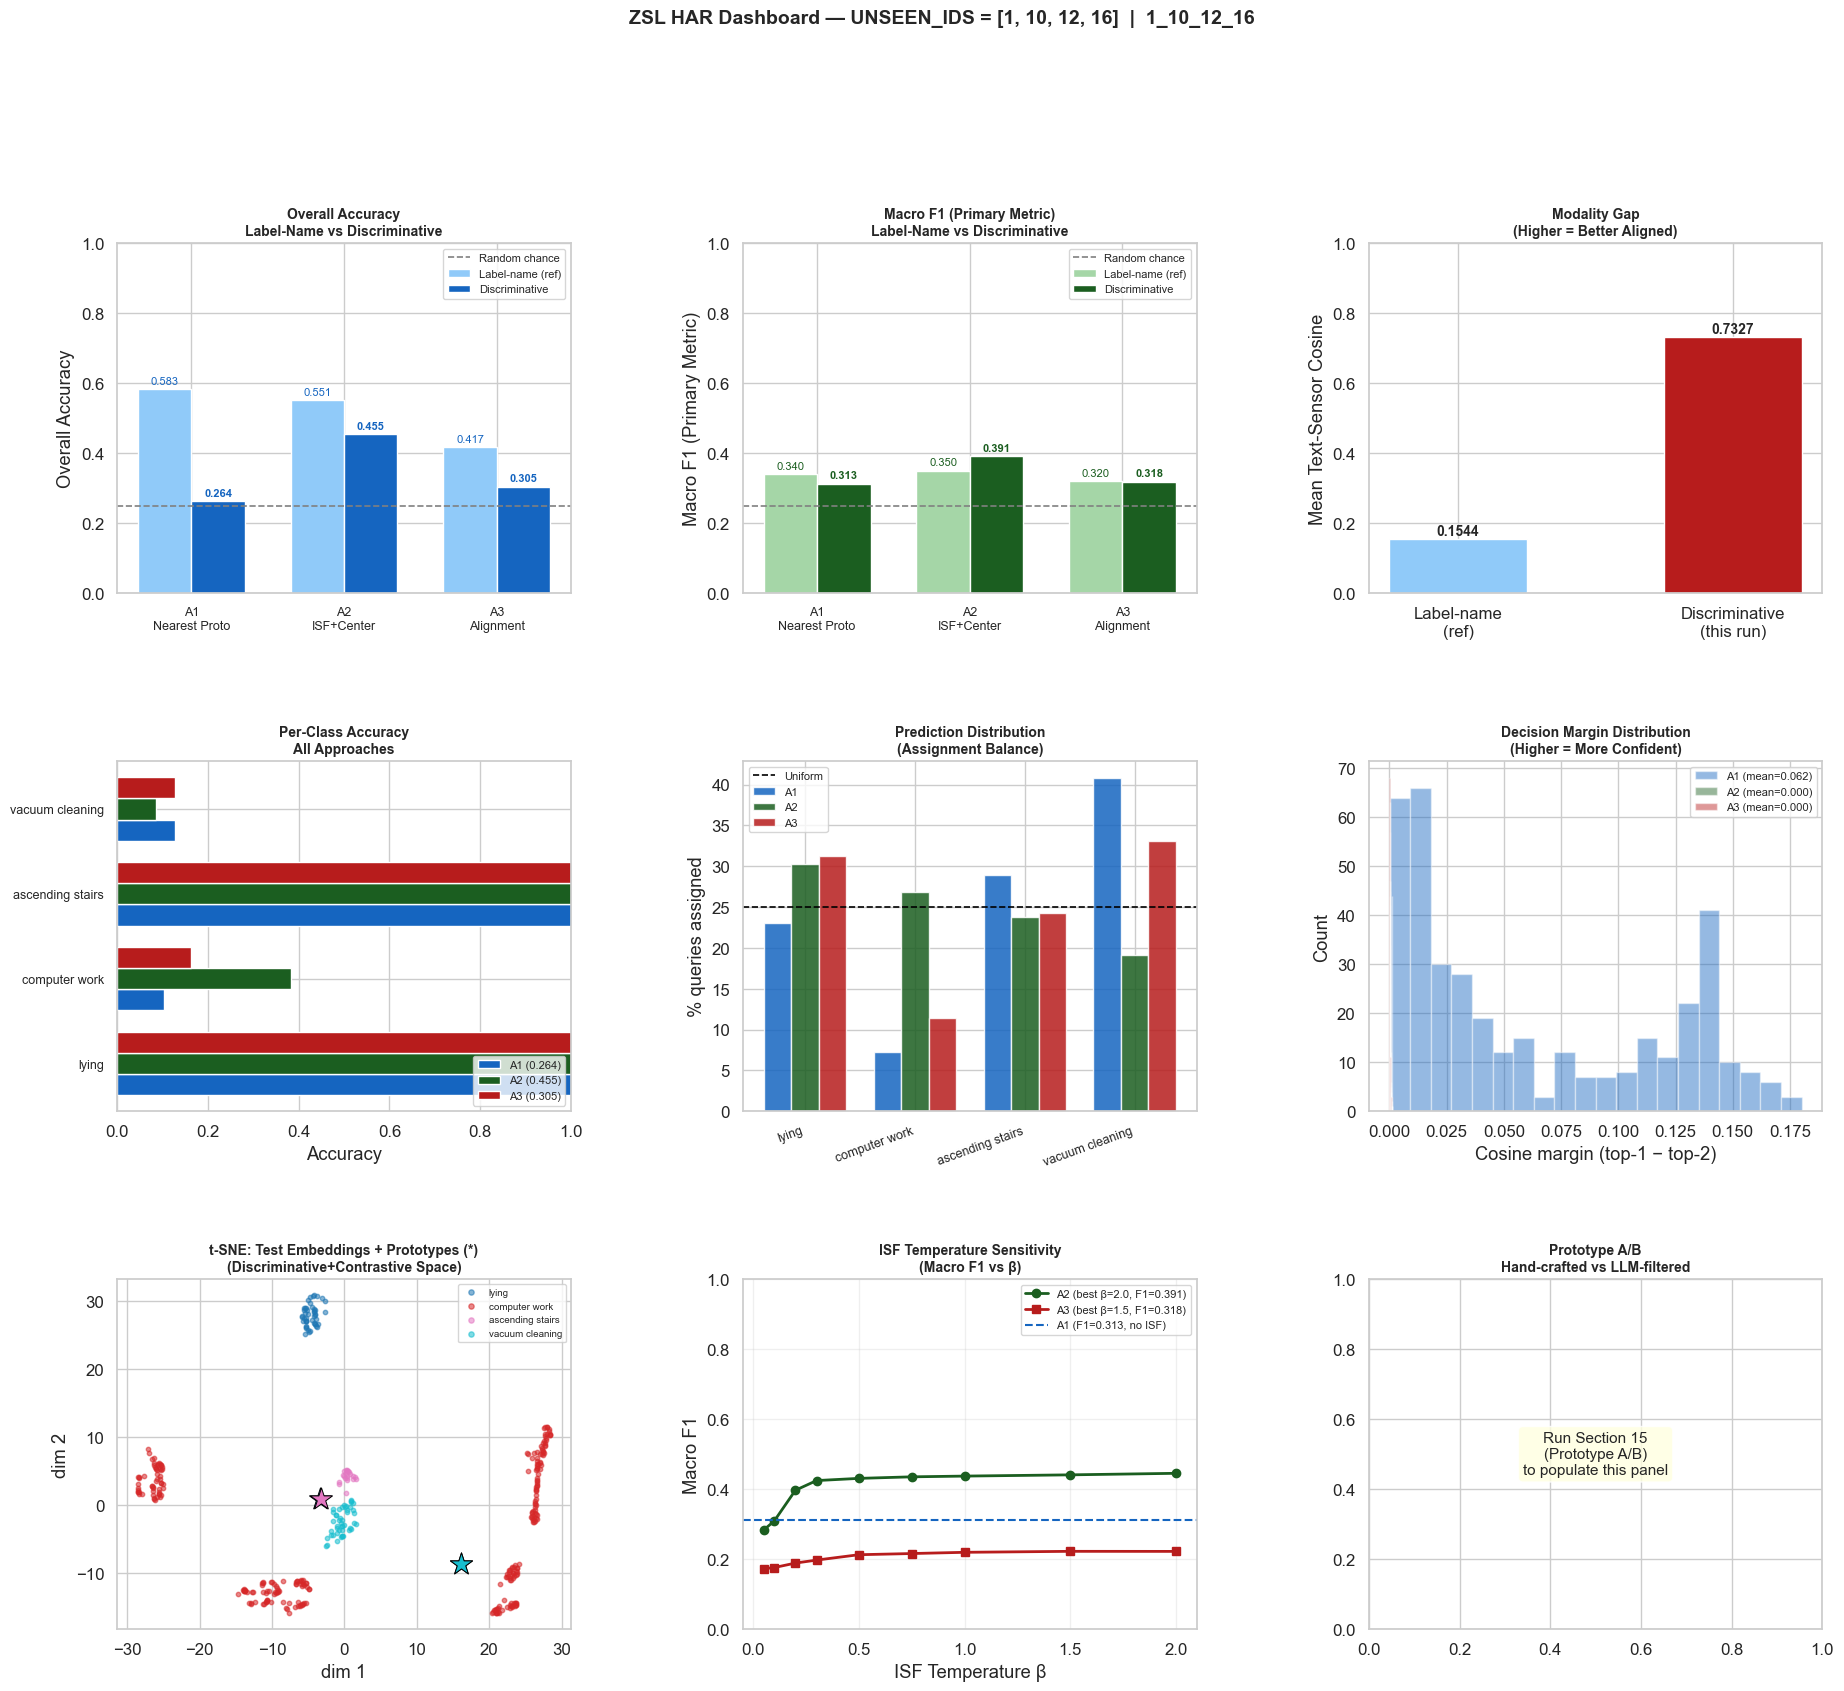

Saved: dashboard_1_10_12_16.png


In [162]:
# ─── Dashboard: all core visualisations in one panel ─────────────────────────
# Mirrors the layout: top row = summary metrics + modality gap,
# middle row = per-class recall + prediction distribution + decision margins,
# bottom row = t-SNE + A/B comparison.

from sklearn.metrics import confusion_matrix
from collections import Counter

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# ── Titles & shared references ───────────────────────────────────────────────
approaches_lbl = ["A1\nNearest Proto", "A2\nISF+Center", "A3\nAlignment"]
accs_disc      = [metrics_a1["acc"],      metrics_a2["acc"],      metrics_a3["acc"]]
f1s_disc       = [metrics_a1["macro_f1"], metrics_a2["macro_f1"], metrics_a3["macro_f1"]]
accs_labels    = [0.5825, 0.5515, 0.4175]
f1s_labels     = [0.34,   0.35,   0.32]
x_s = np.arange(3); w_s = 0.35

# ── TOP-LEFT: Overall Accuracy ───────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.bar(x_s - w_s/2, accs_labels, w_s, label="Label-name (ref)", color="#90CAF9", edgecolor="white")
ax.bar(x_s + w_s/2, accs_disc,   w_s, label="Discriminative",    color="#1565C0", edgecolor="white")
ax.axhline(0.25, ls="--", c="gray", lw=1.2, label="Random chance")
ax.set_xticks(x_s); ax.set_xticklabels(approaches_lbl, fontsize=9)
ax.set_ylabel("Overall Accuracy"); ax.set_ylim(0, 1.0)
ax.set_title("Overall Accuracy\nLabel-Name vs Discriminative", fontweight="bold", fontsize=10)
ax.legend(fontsize=8)
for xi, (v1, v2) in enumerate(zip(accs_labels, accs_disc)):
    ax.text(xi - w_s/2, v1 + 0.015, f"{v1:.3f}", ha="center", fontsize=8, color="#1565C0")
    ax.text(xi + w_s/2, v2 + 0.015, f"{v2:.3f}", ha="center", fontsize=8, fontweight="bold", color="#1565C0")

# ── TOP-MIDDLE: Macro F1 ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.bar(x_s - w_s/2, f1s_labels, w_s, label="Label-name (ref)", color="#A5D6A7", edgecolor="white")
ax.bar(x_s + w_s/2, f1s_disc,   w_s, label="Discriminative",    color="#1B5E20", edgecolor="white")
ax.axhline(0.25, ls="--", c="gray", lw=1.2, label="Random chance")
ax.set_xticks(x_s); ax.set_xticklabels(approaches_lbl, fontsize=9)
ax.set_ylabel("Macro F1 (Primary Metric)"); ax.set_ylim(0, 1.0)
ax.set_title("Macro F1 (Primary Metric)\nLabel-Name vs Discriminative", fontweight="bold", fontsize=10)
ax.legend(fontsize=8)
for xi, (v1, v2) in enumerate(zip(f1s_labels, f1s_disc)):
    ax.text(xi - w_s/2, v1 + 0.015, f"{v1:.3f}", ha="center", fontsize=8, color="#1B5E20")
    ax.text(xi + w_s/2, v2 + 0.015, f"{v2:.3f}", ha="center", fontsize=8, fontweight="bold", color="#1B5E20")

# ── TOP-RIGHT: Modality Gap (bar chart, 3 columns) ───────────────────────────
ax = fig.add_subplot(gs[0, 2])
gap_labels = ["Label-name\n(ref)", "Discriminative\n(this run)"]
gap_vals   = [float(np.mean([label_name_cosines.get(c, 0.0) for c in valid_seen])),
              float(np.mean(cosines_new))]
colors_gap = ["#90CAF9", "#B71C1C"]
bars = ax.bar(gap_labels, gap_vals, color=colors_gap, edgecolor="white", width=0.5)
for bar, val in zip(bars, gap_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Mean Text-Sensor Cosine"); ax.set_ylim(0, 1.0)
ax.set_title("Modality Gap\n(Higher = Better Aligned)", fontweight="bold", fontsize=10)

# ── MID-LEFT: Per-class accuracy (horizontal bar) ───────────────────────────
ax = fig.add_subplot(gs[1, 0])
per_cls_acc = {
    "A1": [float((pred_a1[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN],
    "A2": [float((pred_a2[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN],
    "A3": [float((pred_a3[y_true==c]==c).mean()) if (y_true==c).sum()>0 else 0 for c in UNSEEN],
}
y_pos = np.arange(len(UNSEEN)); h = 0.25
colors_p = ["#1565C0", "#1B5E20", "#B71C1C"]
labels_p  = [f"A1 ({metrics_a1['acc']:.3f})", f"A2 ({metrics_a2['acc']:.3f})", f"A3 ({metrics_a3['acc']:.3f})"]
for i, (key, col, lbl) in enumerate(zip(["A1","A2","A3"], colors_p, labels_p)):
    ax.barh(y_pos + (i-1)*h, per_cls_acc[key], h, label=lbl, color=col, edgecolor="white")
ax.set_yticks(y_pos); ax.set_yticklabels([ACTIVITY_MAP[c] for c in UNSEEN], fontsize=9)
ax.set_xlabel("Accuracy"); ax.set_xlim(0, 1.0)
ax.set_title("Per-Class Accuracy\nAll Approaches", fontweight="bold", fontsize=10)
ax.legend(fontsize=8, loc="lower right")

# ── MID-MIDDLE: Prediction distribution ──────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
names_un    = [ACTIVITY_MAP[c] for c in UNSEEN]
n_total     = len(y_true)
colors_pp   = ["#1565C0", "#1B5E20", "#B71C1C"]
x_pp = np.arange(len(UNSEEN)); w_pp = 0.25
for i, (preds, col, apname) in enumerate(zip([pred_a1, pred_a2, pred_a3], colors_pp,
                                              ["A1", "A2", "A3"])):
    counts = [100 * (preds == c).sum() / n_total for c in UNSEEN]
    ax.bar(x_pp + (i-1)*w_pp, counts, w_pp, label=apname, color=col, edgecolor="white", alpha=0.85)
ax.axhline(100/len(UNSEEN), ls="--", c="black", lw=1.2, label="Uniform")
ax.set_xticks(x_pp); ax.set_xticklabels(names_un, fontsize=9, rotation=20, ha="right")
ax.set_ylabel("% queries assigned"); ax.set_title("Prediction Distribution\n(Assignment Balance)",
                                                   fontweight="bold", fontsize=10)
ax.legend(fontsize=8)

# ── MID-RIGHT: Decision margin distribution ──────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
for preds, sims, col, apname, mets in [
    (pred_a1, sims_a1, "#1565C0", "A1", metrics_a1),
    (pred_a2, scores_a2, "#1B5E20", "A2", metrics_a2),
    (pred_a3, scores_a3, "#B71C1C", "A3", metrics_a3),
]:
    top2    = np.sort(sims, axis=1)[:, -2:]
    margins = top2[:, 1] - top2[:, 0]
    ax.hist(margins, bins=20, alpha=0.45, color=col,
            label=f"{apname} (mean={margins.mean():.3f})", density=False)
ax.set_xlabel("Cosine margin (top-1 − top-2)"); ax.set_ylabel("Count")
ax.set_title("Decision Margin Distribution\n(Higher = More Confident)", fontweight="bold", fontsize=10)
ax.legend(fontsize=8)

# ── BOTTOM-LEFT: t-SNE contrastive space ─────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
palette_d = plt.cm.get_cmap("tab10", len(UNSEEN))
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts4] == cid)
    ax.scatter(Z4_pts[m, 0], Z4_pts[m, 1], s=10, alpha=0.55,
               color=palette_d(k), label=ACTIVITY_MAP[cid])
for k, cid in enumerate(UNSEEN):
    ax.scatter(Z4_star[k, 0], Z4_star[k, 1], marker="*", s=280,
               color=palette_d(k), edgecolors="black", linewidths=0.7, zorder=5)
ax.set_title("t-SNE: Test Embeddings + Prototypes (*)\n(Discriminative+Contrastive Space)",
             fontweight="bold", fontsize=10)
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
ax.legend(fontsize=7, markerscale=1.2)

# ── BOTTOM-MIDDLE: ISF beta sensitivity ──────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
ax.plot(beta_grid, beta_accs_a2, marker="o", lw=2, color="#1B5E20",
        markersize=6, label=f"A2 (best β={best_beta_a2}, F1={metrics_a2['macro_f1']:.3f})")
ax.plot(beta_grid, beta_accs_a3, marker="s", lw=2, color="#B71C1C",
        markersize=6, label=f"A3 (best β={best_beta_a3}, F1={metrics_a3['macro_f1']:.3f})")
ax.axhline(metrics_a1["macro_f1"], ls="--", color="#1565C0", lw=1.5,
           label=f"A1 (F1={metrics_a1['macro_f1']:.3f}, no ISF)")
ax.set_xlabel("ISF Temperature β"); ax.set_ylabel("Macro F1")
ax.set_title("ISF Temperature Sensitivity\n(Macro F1 vs β)", fontweight="bold", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)

# ── BOTTOM-RIGHT: Prototype A/B macro F1 (placeholder if not yet run) ────────
ax = fig.add_subplot(gs[2, 2])
try:
    tags_ab    = ["Hand-crafted discriminative", "LLM-generated + filtered"]
    keys_ab    = ["A1", "A2", "A3"]
    hand_f1_ab = [results[tags_ab[0]]["metrics"][k]["macro_f1"] for k in keys_ab]
    llm_f1_ab  = [results[tags_ab[1]]["metrics"][k]["macro_f1"] for k in keys_ab]
    x_ab = np.arange(3); w_ab = 0.38
    b1_ab = ax.bar(x_ab - w_ab/2, hand_f1_ab, w_ab, label="Hand-crafted", color="#90A4AE", edgecolor="white")
    b2_ab = ax.bar(x_ab + w_ab/2, llm_f1_ab,  w_ab, label="LLM-filtered", color="#1B5E20", edgecolor="white")
    for bars_ab in (b1_ab, b2_ab):
        for bar in bars_ab:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
    ax.axhline(0.25, ls="--", c="gray", lw=1, label="Random chance")
    ax.set_xticks(x_ab); ax.set_xticklabels(["A1 Cosine NN", "A2 ISF+Ctr", "A3 Align+ISF"], fontsize=9)
    ax.set_ylabel("Macro F1"); ax.set_ylim(0, 1.0)
    ax.set_title("Prototype A/B\nHand-crafted vs LLM-filtered", fontweight="bold", fontsize=10)
    ax.legend(fontsize=8)
except (NameError, KeyError):
    ax.text(0.5, 0.5, "Run Section 15\n(Prototype A/B)\nto populate this panel",
            ha="center", va="center", fontsize=11, transform=ax.transAxes,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    ax.set_title("Prototype A/B\nHand-crafted vs LLM-filtered", fontweight="bold", fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.suptitle(f"ZSL HAR Dashboard — UNSEEN_IDS = {UNSEEN_IDS}  |  {dir_string}",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(os.path.join(VIS_DIR, f"dashboard_{dir_string}.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print(f"Saved: dashboard_{dir_string}.png")


## 15. Prototype A/B — Hand-crafted vs LLM-selected

The separability plot (Section 9b) shows the LLM-selected prototypes are more
separable, but separability is a property of the prototypes, not evidence of
better recognition. This section provides the actual comparison: it **retrains
the encoder from scratch for each prototype set** (the prototypes are also the
training targets), runs all three approaches identically, and prints macro F1,
accuracy, and balanced accuracy side by side, plus per-class recall deltas.

Seeds are reset before each run, so the only difference between the two columns
is the prototype matrix — any gap is attributable to prototype construction
alone. Note this trains the encoder **twice**, so it takes roughly double a
normal run.

In [ ]:
# ─── A/B comparison: hand-crafted discriminative vs LLM-selected prototypes ────
# Retrains the encoder FROM SCRATCH for each prototype set (the prototypes are also
# the training targets), then runs all three approaches identically. Seeds are reset
# before each run, so the ONLY thing differing between the two columns is the
# prototype matrix — any gap is attributable to prototype construction alone.
import pandas as pd

def _set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

def train_encoder_on(S_matrix, epochs=EPOCHS, lr=LR, temp=TEMP, patience=PATIENCE, verbose=True):
    _set_seed(SEED)
    S_tensor  = torch.tensor(S_matrix, dtype=torch.float32).to(DEVICE)
    net       = ZSLModel(n_features=N_FEATURES, emb_dim=SEM_DIM).to(DEVICE)
    tr_loader = DataLoader(WindowDataset(X_tr_n, y_tr), batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
    va_loader = DataLoader(WindowDataset(X_val_n, y_val), batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=NUM_WORKERS)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_acc, best_state, bad = 0.0, None, 0
    cand_idx    = torch.tensor([row_idx[c] for c in SEEN], device=DEVICE)
    S_seen_ab   = S_tensor[cand_idx]
    seen_pos_ab = {c: i for i, c in enumerate(SEEN)}
    last_ep = 0
    for ep in range(1, epochs + 1):
        last_ep = ep
        net.train()
        for xb, yb in tr_loader:
            xb  = xb.to(DEVICE)
            if SEEN_ONLY_SOFTMAX:
                tgt = torch.tensor([seen_pos_ab[int(l)] for l in yb.numpy()], device=DEVICE, dtype=torch.long)
                P_ab = S_seen_ab
            else:
                tgt = torch.tensor([row_idx[int(l)] for l in yb.numpy()], device=DEVICE, dtype=torch.long)
                P_ab = S_tensor
            e      = net(xb)
            logits = (e @ P_ab.T) / temp
            loss   = nn.functional.cross_entropy(logits, tgt)
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0); opt.step()
        net.eval()
        proto_v = S_tensor[cand_idx]; yt, yp = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                k = (net(xb.to(DEVICE)) @ proto_v.T).argmax(1).cpu().numpy()
                yt.append(yb.numpy()); yp.append(np.array([SEEN[i] for i in k]))
        vacc = float((np.concatenate(yt) == np.concatenate(yp)).mean())
        sch.step()
        if vacc > best_acc + MIN_DELTA:
            best_acc, bad = vacc, 0
            best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
        if verbose and ep % 10 == 0:
            print(f"    epoch {ep:02d}  val_seen_acc={vacc:.3f}")
    if best_state:
        net.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    if verbose:
        print(f"    done: best val_seen_acc={best_acc:.3f}, stopped at epoch {last_ep}")
    return net

def embed_with(net):
    net.eval()
    with torch.no_grad():
        E  = np.concatenate([net(xb.to(DEVICE)).cpu().numpy() for xb, _ in test_loader])
        yt = np.concatenate([yb.numpy() for _, yb in test_loader])
        Es = np.concatenate([net(xb.to(DEVICE)).cpu().numpy() for xb, _ in seen_ldr])
        Ys = np.concatenate([yb.numpy() for _, yb in seen_ldr])
        if len(X_valu_n) > 0:
            Ev = np.concatenate([net(xb.to(DEVICE)).cpu().numpy() for xb, _ in valu_loader])
            Yv = np.concatenate([yb.numpy() for _, yb in valu_loader])
        else:
            Ev = np.zeros((0, SEM_DIM), dtype=np.float32)
            Yv = np.zeros((0,), dtype=np.int64)
    cents, valid = {}, []
    for cid in SEEN:
        m = (Ys == cid)
        if m.sum() == 0:
            continue
        c = Es[m].mean(0); cents[cid] = c / (np.linalg.norm(c) + 1e-8); valid.append(cid)
    return E, yt, cents, valid, Ev, Yv

def _best_beta(E, P, ids, y):
    f1s = [f1_score(y, inverted_softmax_predict(E, P, b, ids)[0],
                    labels=ids, average="macro", zero_division=0) for b in beta_grid]
    return beta_grid[int(np.argmax(f1s))]

def _use_val():
    return len(VAL_UNSEEN) >= 2

def approaches_on(E, yt, S_matrix, cents, valid, Ev, yv):
    tn = [ACTIVITY_MAP[c] for c in UNSEEN]
    pu = np.stack([S_matrix[row_idx[c]] for c in UNSEEN], 0)
    # Approach 1
    p1 = np.array([UNSEEN[i] for i in (E @ pu.T).argmax(1)], dtype=np.int64)
    m1 = eval_metrics(yt, p1, UNSEEN, tn)
    # Approach 2
    mu = np.vstack([E, S_matrix]).mean(0, keepdims=True)
    Ec, Pc = center_and_renorm(E, mu), center_and_renorm(pu, mu)
    if _use_val() and len(Ev) > 0:
        pv   = np.stack([S_matrix[row_idx[c]] for c in VAL_UNSEEN], 0)
        muv  = np.vstack([Ev, S_matrix]).mean(0, keepdims=True)
        b2   = _best_beta(center_and_renorm(Ev, muv), center_and_renorm(pv, muv), VAL_UNSEEN, yv)
    else:
        b2   = _best_beta(Ec, Pc, UNSEEN, yt)
    p2 = inverted_softmax_predict(Ec, Pc, b2, UNSEEN)[0]
    m2 = eval_metrics(yt, p2, UNSEEN, tn)
    # Approach 3
    Tv = np.stack([S_matrix[row_idx[c]] for c in valid], 0)
    Cv = np.stack([cents[c] for c in valid], 0)
    Kg = [k for k in [3, 5, 7, 9, 11] if k < len(valid)]; lg = [1e-3, 1e-2, 0.1, 1.0, 5.0, 10.0]
    bl, bK, bL = np.inf, Kg[0], lg[0]
    for K in Kg:
        for lam in lg:
            er = loo_pca_ridge(Tv, Cv, K, lam)
            if er < bl: bl, bK, bL = er, K, lam
    W, pT, pC = fit_pca_ridge(Tv, Cv, bK, bL)
    Pa = np.stack([project_unseen_proto(S_matrix[row_idx[c]], W, pT, pC) for c in UNSEEN], 0)
    if _use_val() and len(Ev) > 0:
        Pav = np.stack([project_unseen_proto(S_matrix[row_idx[c]], W, pT, pC) for c in VAL_UNSEEN], 0)
        b3  = _best_beta(Ev, Pav, VAL_UNSEEN, yv)
    else:
        b3  = _best_beta(E, Pa, UNSEEN, yt)
    p3 = inverted_softmax_predict(E, Pa, b3, UNSEEN)[0]
    m3 = eval_metrics(yt, p3, UNSEEN, tn)
    preds  = {"A1": p1, "A2": p2, "A3": p3}
    recall = {a: {c: (float((pr[yt == c] == c).mean()) if (yt == c).sum() else float("nan"))
                  for c in UNSEEN} for a, pr in preds.items()}
    gap = float(np.mean([S_matrix[row_idx[c]] @ cents[c] for c in valid]))
    return {"A1": m1, "A2": m2, "A3": m3}, recall, gap

settings = [("Hand-crafted discriminative", S_disc), ("LLM-generated + filtered", S_llm)]
results  = {}
for tag, S_mat in settings:
    print(f"Training + evaluating: {tag} ...")
    net = train_encoder_on(S_mat)
    E, yt, cents, valid, Ev, yv = embed_with(net)
    mets, recall, gap = approaches_on(E, yt, S_mat, cents, valid, Ev, yv)
    results[tag] = {"metrics": mets, "recall": recall, "gap": gap}
    print(f"    modality gap (mean text-sensor cosine) = {gap:.4f}\n")

tags = [t for t, _ in settings]
rows = []
for ap, apname in [("A1", "A1 Cosine NN"), ("A2", "A2 ISF+Center"), ("A3", "A3 Align+ISF")]:
    for k, kl in [("macro_f1", "Macro F1"), ("acc", "Accuracy"), ("bal_acc", "Bal Acc")]:
        v0 = results[tags[0]]["metrics"][ap][k]; v1 = results[tags[1]]["metrics"][ap][k]
        rows.append({"Approach": apname, "Metric": kl,
                     "Hand-crafted": round(v0, 4), "LLM-filtered": round(v1, 4),
                     "Delta": round(v1 - v0, 4)})
cmp_df = pd.DataFrame(rows)
print("=" * 70)
print("PROTOTYPE A/B  —  same split, same encoder setup, prototypes only differ")
print("=" * 70)
print(cmp_df.to_string(index=False))
print(f"\nModality gap:  hand-crafted={results[tags[0]]['gap']:.4f}   LLM={results[tags[1]]['gap']:.4f}")

print("\nPer-class recall (A2 ISF+Center):  hand-crafted -> LLM  (delta)")
for c in UNSEEN:
    r0 = results[tags[0]]["recall"]["A2"][c]; r1 = results[tags[1]]["recall"]["A2"][c]
    print(f"  {ACTIVITY_MAP[c]:<24} {r0:.2f} -> {r1:.2f}  ({r1 - r0:+.2f})")

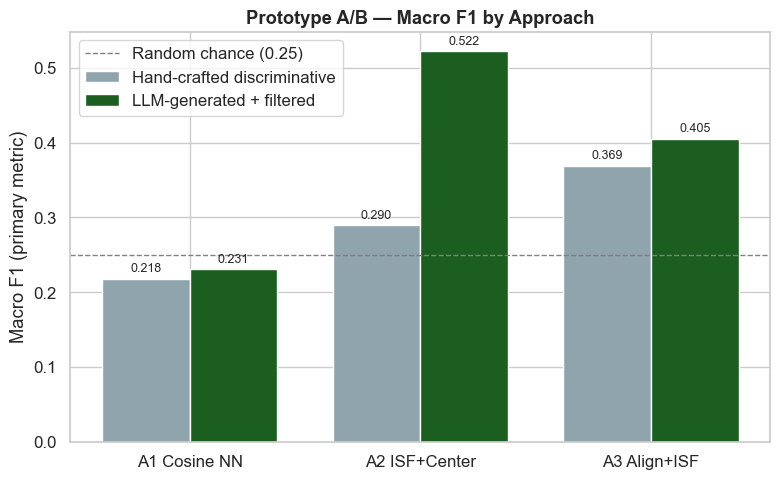

Saved: prototype_ab_macro_f1.png


In [68]:
# ─── Visualisation: macro-F1 A/B by approach ──────────────────────────────────
approaches = ["A1 Cosine NN", "A2 ISF+Center", "A3 Align+ISF"]
keys       = ["A1", "A2", "A3"]
hand_f1    = [results[tags[0]]["metrics"][k]["macro_f1"] for k in keys]
llm_f1     = [results[tags[1]]["metrics"][k]["macro_f1"] for k in keys]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(approaches)); w = 0.38
b1 = ax.bar(x - w/2, hand_f1, w, label="Hand-crafted discriminative", color="#90A4AE", edgecolor="white")
b2 = ax.bar(x + w/2, llm_f1,  w, label="LLM-generated + filtered",    color="#1B5E20", edgecolor="white")
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(0.25, ls="--", c="gray", lw=1, label="Random chance (0.25)")
ax.set_xticks(x); ax.set_xticklabels(approaches)
ax.set_ylabel("Macro F1 (primary metric)")
ax.set_title("Prototype A/B — Macro F1 by Approach", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "prototype_ab_macro_f1.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: prototype_ab_macro_f1.png")

## 16. UniMTS Export (optional)

Writes the held-out unseen windows in the format expected by UniMTS
`evaluate_custom.py`, so the pre-trained motion encoder can be run as an external
zero-shot baseline on the same split. Nothing in this cell affects the pipeline
above; it only reads `X_test_u`.


In [ ]:
# ─── Export windows for UniMTS (evaluate_custom.py) ──────────────────────────
# UniMTS (Zhang et al., NeurIPS 2024, arXiv:2410.19818) is pre-trained ONLY on
# physics-simulated HumanML3D data, so evaluating it on PAMAP2 introduces no
# contamination. It expects, per joint, the channel order
#   (acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z)
# concatenated across joints, in m/s^2, un-normalised. PAMAP2 acc16 is already
# in m/s^2, so no unit conversion is needed. We export the RAW windows
# (X_test_u, not X_test_u_n) because UniMTS applies its own normalisation.

RUN_UNIMTS_EXPORT = False      # set True to write the export

if RUN_UNIMTS_EXPORT:
    import json as _json

    UNIMTS_COLS = []
    for loc in ["hand", "chest", "ankle"]:
        UNIMTS_COLS += [f"{loc}_acc16_x", f"{loc}_acc16_y", f"{loc}_acc16_z",
                        f"{loc}_gyro_x",  f"{loc}_gyro_y",  f"{loc}_gyro_z"]
    missing = [c for c in UNIMTS_COLS if c not in FEATURE_COLS]
    assert not missing, f"missing columns for UniMTS export: {missing}"
    ch_idx = [FEATURE_COLS.index(c) for c in UNIMTS_COLS]

    EXPORT_DIR = "unimts_export"
    os.makedirs(EXPORT_DIR, exist_ok=True)

    X_um = X_test_u[:, :, ch_idx].astype(np.float32)
    y_um = np.array([UNSEEN.index(int(c)) for c in y_test_u], dtype=np.int64)

    np.save(os.path.join(EXPORT_DIR, "X_test.npy"), X_um)
    np.save(os.path.join(EXPORT_DIR, "y_test.npy"), y_um)

    # Label descriptions: uses whichever prototype text set is active.
    _desc_src = LLM_DESC if USE_LLM_PROTOTYPES else DISCRIMINATIVE_DESC
    with open(os.path.join(EXPORT_DIR, "pamap2_unseen.json"), "w") as f:
        _json.dump({"label_dictionary": {str(i): [_desc_src[c]] for i, c in enumerate(UNSEEN)}},
                   f, indent=2)

    print(f"Exported {X_um.shape} to {os.path.abspath(EXPORT_DIR)}")
    print("Channels:", UNIMTS_COLS)
    print("\nRun from the UniMTS repo:")
    print("  python evaluate_custom.py \\")
    print("    --batch_size 64 --checkpoint ./checkpoint/UniMTS.pth \\")
    print(f"    --X_path {EXPORT_DIR}/X_test.npy \\")
    print(f"    --y_path {EXPORT_DIR}/y_test.npy \\")
    print(f"    --config_path {EXPORT_DIR}/pamap2_unseen.json \\")
    print("    --joint_list <hand> <chest> <ankle> \\")
    print("    --original_sampling_rate 100")
    print("\nNOTE: copy --joint_list verbatim from the PAMAP2 entry in the")
    print("UniMTS_data release rather than reading it off joint_assignment.png.")
    print("NOTE: these descriptions were selected in SBERT space; UniMTS pairs")
    print("with the CLIP text encoder, so re-run the selection in CLIP space")
    print("before treating the prototype set as tuned.")
else:
    print("RUN_UNIMTS_EXPORT = False — no files written.")
